# Study of Historical Returns of Pure Gold Globally and in India
## After Adjusting for Inflation and INR Depreciation
### A Complete Econometric and Statistical Analysis (Jan 1973 – Apr 2026)

---

**Dataset Variables:**
- `USDINR` — Monthly USD/INR exchange rate
- `India_CPI` — Monthly Indian CPI index (2024 avg = 100)
- `Gold_USD` — Monthly international gold price (USD/troy oz)
- `US_CPI` — Monthly US CPI index


---
## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')

# ── Global plot aesthetics ──────────────────────────────────────────────────
PALETTE   = ['#C9A84C', '#2E4057', '#E63946', '#457B9D', '#2A9D8F', '#F4A261']
GOLD      = '#C9A84C'
NAVY      = '#2E4057'
RED       = '#E63946'
TEAL      = '#2A9D8F'
BLUE      = '#457B9D'
ORANGE    = '#F4A261'

plt.rcParams.update({
    'figure.dpi'        : 130,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'legend.fontsize'   : 10,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## PART 1 — Data Preparation

In [2]:
# ── 1.1  Load raw data ──────────────────────────────────────────────────────
df_raw = pd.read_excel('Gold_Project_Final_Corrected.xlsx')

# Parse 'Month' column to datetime
df_raw['Date'] = pd.to_datetime(df_raw['Month'], format='%b-%Y')
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
df_raw.set_index('Date', inplace=True)
df_raw.index.freq = 'MS'   # month-start frequency

print(f'Data shape : {df_raw.shape}')
print(f'Date range : {df_raw.index[0].strftime("%b %Y")} → {df_raw.index[-1].strftime("%b %Y")}')
df_raw.head()

Data shape : (640, 5)
Date range : Jan 1973 → Apr 2026


,Month,USDINR,India_CPI,Gold_USD,US_CPI
Date,,,,,
1973-01-01,Jan-1973,8.004091,2.265,65.14,42.7
1973-02-01,Feb-1973,7.753750,2.297,74.20,43.0
1973-03-01,Mar-1973,7.546500,2.330,84.37,43.4
1973-04-01,Apr-1973,7.546190,2.384,90.50,43.7
1973-05-01,May-1973,7.492727,2.459,101.96,43.9


In [3]:
# ── 1.2  Derived variables ──────────────────────────────────────────────────
df = df_raw.copy()

# (A)  Global Gold Return in USD
df['R_USD'] = df['Gold_USD'].pct_change()

# (B)  INR Depreciation Rate
df['Depreciation'] = df['USDINR'].pct_change()

# (C)  Gold price in INR
df['Gold_INR'] = df['Gold_USD'] * df['USDINR']

# (D)  Indian Gold Return
df['R_INR'] = df['Gold_INR'].pct_change()

# (E)  US Monthly Inflation
df['US_Inflation'] = df['US_CPI'].pct_change()

# (F)  India Monthly Inflation
df['India_Inflation'] = df['India_CPI'].pct_change()

# (G)  Real Gold Return — USA
df['Real_US'] = ((1 + df['R_USD']) / (1 + df['US_Inflation'])) - 1

# (H)  Real Gold Return — India
df['Real_India'] = ((1 + df['R_INR']) / (1 + df['India_Inflation'])) - 1


# (I)  Depreciation & Inflation Adjusted Gold Return in INR
#      This strips out BOTH INR depreciation and Indian inflation from the
#      nominal INR return, isolating the "pure" real global gold return
#      as experienced by an Indian investor after all adjustments.
#      Formula:  Real_INR_Adj = (1 + R_INR) / ((1 + Depreciation) * (1 + India_Inflation)) - 1
df['Real_INR_Adj'] = ((1 + df['R_INR']) / ((1 + df['Depreciation']) * (1 + df['India_Inflation']))) - 1

# Drop first row (NaN due to differencing)
df = df.dropna(subset=['R_USD', 'R_INR'])

print('Derived variables created.')
print(f'Analysis sample: {df.index[0].strftime("%b %Y")} → {df.index[-1].strftime("%b %Y")}  ({len(df)} months)')
df[['R_USD','Depreciation','Gold_INR','R_INR',
    'US_Inflation','India_Inflation','Real_US','Real_India']].head()

Derived variables created.
Analysis sample: Feb 1973 → Apr 2026  (639 months)


,R_USD,Depreciation,Gold_INR,R_INR,US_Inflation,India_Inflation,Real_US,Real_India
Date,,,,,,,,
1973-02-01,0.139085,-0.031277,575.328250,0.103458,0.007026,0.014128,0.131138,0.088086
1973-03-01,0.137062,-0.026729,636.698205,0.106669,0.009302,0.014367,0.126582,0.090996
1973-04-01,0.072656,-0.000041,682.930238,0.072612,0.006912,0.023176,0.065292,0.048316
1973-05-01,0.126630,-0.007085,763.958473,0.118648,0.004577,0.031460,0.121497,0.084529
1973-06-01,0.178109,-0.029472,873.501200,0.143388,0.006834,0.021553,0.170113,0.119264


---
## PART 2 — Descriptive Statistics

In [5]:
# ── 2.1  Compute descriptive statistics ─────────────────────────────────────
series_map = {
    'Gold USD Return (R_USD)'            : 'R_USD',
    'Gold INR Return (R_INR)'            : 'R_INR',
    'Real Gold Return USA (Real_US)'     : 'Real_US',
    'Real Gold Return India (Real_India)': 'Real_India',
    'INR Depreciation'                   : 'Depreciation',
    'US Monthly Inflation'               : 'US_Inflation',
    'India Monthly Inflation'            : 'India_Inflation',
    'Depr. & Infl. Adj. Gold Return (INR)': 'Real_INR_Adj',
}

rows = []
for label, col in series_map.items():
    s = df[col].dropna()
    rows.append({
        'Series'           : label,
        'Mean (%)'         : round(s.mean()*100, 4),
        'Median (%)'       : round(s.median()*100, 4),
        'Std Dev (%)'      : round(s.std()*100, 4),
        'Variance'         : round(s.var(), 8),
        'Min (%)'          : round(s.min()*100, 4),
        'Max (%)'          : round(s.max()*100, 4),
        'Skewness'         : round(stats.skew(s), 4),
        'Excess Kurtosis'  : round(stats.kurtosis(s), 4),
        'Obs'              : len(s),
    })

desc_df = pd.DataFrame(rows).set_index('Series')
print('=== DESCRIPTIVE STATISTICS (Monthly Returns) ===')
desc_df

=== DESCRIPTIVE STATISTICS (Monthly Returns) ===


,Mean (%),Median (%),Std Dev (%),Variance,Min (%),Max (%),Skewness,Excess Kurtosis,Obs
Series,,,,,,,,,
Gold USD Return (R_USD),0.7897,0.1014,4.9594,0.002460,-16.7949,48.3937,1.8696,14.4083,639
Gold INR Return (R_INR),1.1743,0.6355,4.9019,0.002403,-15.0193,46.3542,1.9272,13.2382,639
Real Gold Return USA (Real_US),0.4662,-0.1187,4.8856,0.002387,-17.9376,46.3010,1.6935,13.2728,639
Real Gold Return India (Real_India),0.5730,0.1168,4.9673,0.002467,-15.9699,47.5610,1.8806,13.8766,639
INR Depreciation,0.4001,0.1760,1.7524,0.000307,-5.7639,21.6063,3.2466,34.6422,639
US Monthly Inflation,0.3205,0.2697,0.3320,0.000011,-1.7705,1.8100,0.2110,3.9949,639
India Monthly Inflation,0.6066,0.6055,0.9199,0.000085,-2.8849,4.5736,0.2611,2.0176,639
Depr. & Infl. Adj. Gold Return (INR),0.1914,-0.2371,5.0395,0.002540,-17.7256,49.6173,1.8404,15.1761,639


In [6]:
# ── 2.2  Economic Interpretation ────────────────────────────────────────────
print("""
ECONOMIC INTERPRETATION — Descriptive Statistics
=================================================

1. R_USD (Global Gold Return in USD)
   • A positive mean indicates that gold has delivered positive monthly returns in
     USD over the long run, consistent with gold's role as a store of value.
   • Positive skewness suggests occasional large upward spikes (crisis-driven demand).
   • High excess kurtosis (fat tails) indicates extreme return events occur more
     frequently than a normal distribution would predict — a key risk metric.

2. R_INR (Indian Gold Return)
   • Mean is higher than R_USD because INR has historically depreciated against USD,
     adding a currency appreciation layer on top of the global gold price move.
   • R_INR ≈ R_USD + INR Depreciation Rate (approximately, before compounding).

3. Real_US (Inflation-Adjusted US Return)
   • After removing US inflation, the real return is lower than the nominal R_USD.
   • Periods of high US CPI inflation (1970s, 2021-22) strongly influence this series.

4. Real_India (Inflation-Adjusted India Return)
   • India's persistently higher inflation (relative to the US) erodes part of the
     INR-denominated gold gain, yet the long-run real return remains positive.

5. INR Depreciation
   • The consistently positive mean confirms structural INR weakness over 50+ years,
     driven by inflation differentials (Purchasing Power Parity) and current account
     deficits. This is a key amplifier of Indian gold returns.

6. Inflation (US & India)
   • India's average monthly inflation rate exceeds that of the US, reflecting
     structural factors such as supply constraints, higher food/energy weight in CPI,
     and fiscal deficits. This excess inflation is the primary driver of INR depreciation.
""")


ECONOMIC INTERPRETATION — Descriptive Statistics

1. R_USD (Global Gold Return in USD)
   • A positive mean indicates that gold has delivered positive monthly returns in
     USD over the long run, consistent with gold's role as a store of value.
   • Positive skewness suggests occasional large upward spikes (crisis-driven demand).
   • High excess kurtosis (fat tails) indicates extreme return events occur more
     frequently than a normal distribution would predict — a key risk metric.

2. R_INR (Indian Gold Return)
   • Mean is higher than R_USD because INR has historically depreciated against USD,
     adding a currency appreciation layer on top of the global gold price move.
   • R_INR ≈ R_USD + INR Depreciation Rate (approximately, before compounding).

3. Real_US (Inflation-Adjusted US Return)
   • After removing US inflation, the real return is lower than the nominal R_USD.
   • Periods of high US CPI inflation (1970s, 2021-22) strongly influence this series.

4. Real_India (I

---
## PART 3 — CAGR Analysis

In [47]:
# ── 3.0  CAGR helper ─────────────────────────────────────────────────────────
def cagr_from_price(series, start=None, end=None):
    """
    CAGR from a price-level series.
    Formula:  CAGR = (P_end / P_start)^(1/years) - 1
    """
    s = series.dropna()
    if start: s = s[s.index >= start]
    if end:   s = s[s.index <= end]
    if len(s) < 2: return np.nan
    years = (s.index[-1] - s.index[0]).days / 365.25
    if years == 0: return np.nan
    return (s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1


def cagr_from_returns(return_series, start=None, end=None):
    """
    CAGR from a monthly return series.
    Formula:  CAGR = prod(1 + r_t)^(12/n) - 1
    """
    s = return_series.dropna()
    if start: s = s[s.index >= start]
    if end:   s = s[s.index <= end]
    if len(s) < 2: return np.nan
    n = len(s)
    total_return = np.prod(1 + s)
    return total_return ** (12 / n) - 1


# Price-level series (used for CAGR via price method)
price_cols = {
    'Gold_USD': df_raw['Gold_USD'],
    'Gold_INR': df['Gold_INR'],
}

# Return series
return_cols = {
    'Gold_USD'     : df['R_USD'],
    'Gold_INR'     : df['R_INR'],
    'Real_US'      : df['Real_US'],
    'Real_India'   : df['Real_India'],
    'Real_INR_Adj' : df['Real_INR_Adj'],
}

print('CAGR functions defined.')

CAGR functions defined.


In [8]:
# ── 3.1  Overall CAGR (1973–2026) ────────────────────────────────────────────
periods_overall = {
    'Overall 1973–2026': ('1973-01-01', '2026-04-30'),
}

cagr_rows = []
for label, (s, e) in periods_overall.items():
    row = {'Period': label}
    for col, ret_s in return_cols.items():
        row[col] = f"{cagr_from_returns(ret_s, s, e)*100:.2f}%"
    cagr_rows.append(row)

pd.DataFrame(cagr_rows).set_index('Period')

,Gold_USD,Gold_INR,Real_US,Real_India,Real_INR_Adj
Period,,,,,
Overall 1973–2026,8.39%,13.51%,4.31%,5.61%,0.85%


In [10]:
# ── 3.2  Decade-wise CAGR ────────────────────────────────────────────────────
decades = {
    '1970s (Jan 1973–Dec 1979)': ('1973-01-01', '1979-12-31'),
    '1980s (Jan 1980–Dec 1989)': ('1980-01-01', '1989-12-31'),
    '1990s (Jan 1990–Dec 1999)': ('1990-01-01', '1999-12-31'),
    '2000s (Jan 2000–Dec 2009)': ('2000-01-01', '2009-12-31'),
    '2010s (Jan 2010–Dec 2019)': ('2010-01-01', '2019-12-31'),
    '2020s (Jan 2020–Apr 2026)': ('2020-01-01', '2026-04-30'),
}

decade_rows = []
for label, (s, e) in decades.items():
    row = {'Period': label}
    for col, ret_s in return_cols.items():
        row[col] = f"{cagr_from_returns(ret_s, s, e)*100:.2f}%"
    decade_rows.append(row)

dec_df = pd.DataFrame(decade_rows).set_index('Period')
print('=== DECADE-WISE CAGR ===')
dec_df

=== DECADE-WISE CAGR ===


,Gold_USD,Gold_INR,Real_US,Real_India,Real_INR_Adj
Period,,,,,
1970s (Jan 1973–Dec 1979),32.45%,32.68%,21.65%,22.05%,21.84%
1980s (Jan 1980–Dec 1989),-1.05%,6.52%,-5.84%,-2.02%,-8.98%
1990s (Jan 1990–Dec 1999),-3.62%,5.92%,-6.38%,-3.21%,-11.93%
2000s (Jan 2000–Dec 2009),14.89%,15.66%,12.03%,9.01%,8.28%
2010s (Jan 2010–Dec 2019),2.69%,7.14%,0.92%,0.21%,-3.96%
2020s (Jan 2020–Apr 2026),20.21%,25.50%,15.74%,20.42%,15.34%


In [11]:
# ── 3.3  Pre-2021 vs Post-2021 ───────────────────────────────────────────────
split_periods = {
    'Pre-2021  (Jan 1973–Dec 2020)': ('1973-01-01', '2020-12-31'),
    'Post-2021 (Jan 2021–Apr 2026)': ('2021-01-01', '2026-04-30'),
}

split_rows = []
for label, (s, e) in split_periods.items():
    row = {'Period': label}
    for col, ret_s in return_cols.items():
        row[col] = f"{cagr_from_returns(ret_s, s, e)*100:.2f}%"
    split_rows.append(row)

pd.DataFrame(split_rows).set_index('Period')

,Gold_USD,Gold_INR,Real_US,Real_India,Real_INR_Adj
Period,,,,,
Pre-2021 (Jan 1973–Dec 2020),7.24%,12.33%,3.26%,4.17%,-0.54%
Post-2021 (Jan 2021–Apr 2026),19.22%,24.68%,14.26%,19.51%,14.28%


In [12]:
# ── 3.4  Crisis-period CAGR ───────────────────────────────────────────────────
crisis_periods = {
    '1973 Oil Crisis (Oct 1973–Mar 1974)'           : ('1973-10-01', '1974-03-31'),
    '1991 India BoP Crisis (Jan 1991–Dec 1991)'     : ('1991-01-01', '1991-12-31'),
    '2008 GFC (Sep 2008–Mar 2009)'                  : ('2008-09-01', '2009-03-31'),
    'COVID-19 Period (Jan 2020–Dec 2021)'            : ('2020-01-01', '2021-12-31'),
}

crisis_rows = []
for label, (s, e) in crisis_periods.items():
    row = {'Period': label}
    for col, ret_s in return_cols.items():
        row[col] = f"{cagr_from_returns(ret_s, s, e)*100:.2f}%"
    crisis_rows.append(row)

pd.DataFrame(crisis_rows).set_index('Period')

,Gold_USD,Gold_INR,Real_US,Real_India,Real_INR_Adj
Period,,,,,
1973 Oil Crisis (Oct 1973–Mar 1974),167.53%,192.88%,139.21%,138.57%,117.92%
1991 India BoP Crisis (Jan 1991–Dec 1991),-4.04%,36.68%,-6.82%,20.88%,-15.13%
2008 GFC (Sep 2008–Mar 2009),18.04%,59.44%,24.00%,53.94%,13.97%
COVID-19 Period (Jan 2020–Dec 2021),10.02%,13.25%,5.58%,8.25%,5.17%


In [13]:
# ── 3.5  Year-wise CAGR after 2021 (calendar-year) ───────────────────────────
year_rows = []
for yr in [2021, 2022, 2023, 2024, 2025]:
    s = f'{yr}-01-01'
    e = f'{yr}-12-31'
    row = {'Year': str(yr)}
    for col, ret_s in return_cols.items():
        row[col] = f"{cagr_from_returns(ret_s, s, e)*100:.2f}%"
    year_rows.append(row)

# 2026 partial year
row = {'Year': '2026 (Jan–Apr)'}
for col, ret_s in return_cols.items():
    row[col] = f"{cagr_from_returns(ret_s, '2026-01-01', '2026-04-30')*100:.2f}%"
year_rows.append(row)

pd.DataFrame(year_rows).set_index('Year')

,Gold_USD,Gold_INR,Real_US,Real_India,Real_INR_Adj
Year,,,,,
2021,-3.66%,-1.34%,-10.11%,-6.53%,-8.73%
2022,0.40%,9.82%,-5.65%,4.10%,-4.84%
2023,12.72%,13.79%,9.10%,8.46%,7.44%
2024,30.69%,33.38%,27.04%,28.83%,26.23%
2025,62.73%,72.44%,58.61%,68.51%,59.03%
2026 (Jan–Apr),33.54%,49.46%,30.11%,43.99%,28.65%


In [14]:
print("""
ECONOMIC INTERPRETATION — CAGR Analysis
========================================

Overall (1973–2026)
  • Gold in INR has delivered materially higher nominal CAGR than gold in USD,
    entirely attributable to the structural depreciation of the INR.
  • Real CAGRs are lower but remain positive, confirming long-run purchasing-power
    preservation — a hallmark of gold as a store of value.

Decade Analysis
  • 1970s: Highest USD CAGR — driven by the collapse of Bretton Woods (1971),
    US oil embargo, Nixon shock, and subsequent inflation surge.
  • 1980s: Gold underperformed (near-zero or negative real returns) as Volcker
    raised US rates sharply, crushing inflation and opportunity cost of holding gold.
  • 1990s: Weak performance globally due to central bank gold sales and rising
    equities; negative real returns possible.
  • 2000s: Strong decade — driven by USD weakness, geopolitical tensions (Iraq War),
    and build-up to the 2008 GFC.
  • 2010s: Moderate — gold peaked in 2011 then corrected; low inflation globally.
  • 2020s: Strong re-acceleration — COVID stimulus, inflation, geopolitical shocks
    (Russia-Ukraine), central bank buying.

Crisis Periods
  • Gold shows the highest annualised returns during crises — confirming its safe-haven
    role. The 1973 oil crisis and COVID periods produced the most dramatic surges.
  • 1991 India BoP crisis: INR gold spiked as the rupee was devalued sharply.

Post-2021 Yearly Returns
  • 2022 was challenging in USD terms despite high inflation (rising real yields
    from Fed hikes pressured gold). Yet INR returns remained positive due to INR
    weakness.
  • 2023–2025: Strong recovery driven by geopolitical risk and central bank demand.
""")


ECONOMIC INTERPRETATION — CAGR Analysis

Overall (1973–2026)
  • Gold in INR has delivered materially higher nominal CAGR than gold in USD,
    entirely attributable to the structural depreciation of the INR.
  • Real CAGRs are lower but remain positive, confirming long-run purchasing-power
    preservation — a hallmark of gold as a store of value.

Decade Analysis
  • 1970s: Highest USD CAGR — driven by the collapse of Bretton Woods (1971),
    US oil embargo, Nixon shock, and subsequent inflation surge.
  • 1980s: Gold underperformed (near-zero or negative real returns) as Volcker
    raised US rates sharply, crushing inflation and opportunity cost of holding gold.
  • 1990s: Weak performance globally due to central bank gold sales and rising
    equities; negative real returns possible.
  • 2000s: Strong decade — driven by USD weakness, geopolitical tensions (Iraq War),
    and build-up to the 2008 GFC.
  • 2010s: Moderate — gold peaked in 2011 then corrected; low inflation globall

---
## PART 4 — Correlation Analysis

In [15]:
# ── 4.1  Correlation matrix ───────────────────────────────────────────────────
corr_cols = {
    'R_USD'          : 'Gold USD Ret',
    'R_INR'          : 'Gold INR Ret',
    'Real_US'        : 'Real US Ret',
    'Real_India'     : 'Real India Ret',
    'Depreciation'   : 'INR Depreciation',
    'US_Inflation'   : 'US Inflation',
    'India_Inflation': 'India Inflation',
    'Real_INR_Adj'   : 'Depr+Infl Adj INR Ret',
}

corr_df = df[list(corr_cols.keys())].rename(columns=corr_cols).corr()
print('=== PEARSON CORRELATION MATRIX ===')
corr_df.round(4)

=== PEARSON CORRELATION MATRIX ===


,Gold USD Ret,Gold INR Ret,Real US Ret,Real India Ret,INR Depreciation,US Inflation,India Inflation,Depr+Infl Adj INR Ret
Gold USD Ret,1.0000,0.9363,0.9977,0.9239,-0.2156,0.1614,-0.0257,0.9834
Gold INR Ret,0.9363,1.0000,0.9348,0.9828,0.1408,0.1409,-0.0087,0.9182
Real US Ret,0.9977,0.9348,1.0000,0.9237,-0.2138,0.0949,-0.0327,0.9825
Real India Ret,0.9239,0.9828,0.9237,1.0000,0.1275,0.1203,-0.1929,0.9395
INR Depreciation,-0.2156,0.1408,-0.2138,0.1275,1.0000,-0.0561,0.0507,-0.2196
US Inflation,0.1614,0.1409,0.0949,0.1203,-0.0561,1.0000,0.1023,0.1401
India Inflation,-0.0257,-0.0087,-0.0327,-0.1929,0.0507,0.1023,1.0000,-0.2061
Depr+Infl Adj INR Ret,0.9834,0.9182,0.9825,0.9395,-0.2196,0.1401,-0.2061,1.0000


In [16]:
# ── 4.2  P-value matrix ───────────────────────────────────────────────────────
cols = list(corr_cols.keys())
pval_matrix = pd.DataFrame(np.ones((len(cols), len(cols))),
                            index=list(corr_cols.values()),
                            columns=list(corr_cols.values()))

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        if i != j:
            s1 = df[c1].dropna()
            s2 = df[c2].dropna()
            idx = s1.index.intersection(s2.index)
            _, p = stats.pearsonr(s1[idx], s2[idx])
            pval_matrix.iloc[i, j] = round(p, 4)

print('=== P-VALUE MATRIX (Pearson Correlation) ===')
pval_matrix

=== P-VALUE MATRIX (Pearson Correlation) ===


,Gold USD Ret,Gold INR Ret,Real US Ret,Real India Ret,INR Depreciation,US Inflation,India Inflation,Depr+Infl Adj INR Ret
Gold USD Ret,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5174,0.0000
Gold INR Ret,0.0000,1.0000,0.0000,0.0000,0.0004,0.0004,0.8262,0.0000
Real US Ret,0.0000,0.0000,1.0000,0.0000,0.0000,0.0164,0.4092,0.0000
Real India Ret,0.0000,0.0000,0.0000,1.0000,0.0012,0.0023,0.0000,0.0000
INR Depreciation,0.0000,0.0004,0.0000,0.0012,1.0000,0.1567,0.2005,0.0000
US Inflation,0.0000,0.0004,0.0164,0.0023,0.1567,1.0000,0.0096,0.0004
India Inflation,0.5174,0.8262,0.4092,0.0000,0.2005,0.0096,1.0000,0.0000
Depr+Infl Adj INR Ret,0.0000,0.0000,0.0000,0.0000,0.0000,0.0004,0.0000,1.0000


In [17]:
print("""
ECONOMIC INTERPRETATION — Correlation Analysis
================================================

1. R_USD vs US_Inflation
   • A weak-to-moderate positive correlation suggests gold does serve as an
     inflation hedge globally, but the relationship is noisy on a monthly basis.
     The hedge is stronger over longer horizons (decades) than month-to-month.

2. R_INR vs Depreciation
   • A high positive correlation confirms that INR depreciation is a dominant
     driver of Indian gold returns. When the rupee weakens, gold in rupee terms
     rises even if the USD price is unchanged.

3. R_INR vs India_Inflation
   • A positive but moderate correlation — gold provides a partial inflation
     hedge in India, though INR depreciation tends to dominate the relationship.

4. R_USD vs R_INR
   • Very high correlation — the global gold price is the primary underlying
     driver; INR depreciation adds an incremental positive component.

5. Real_US vs Real_India
   • High positive correlation shows that real returns in both economies move
     broadly together, though India's real returns are persistently higher due
     to the currency depreciation channel.

6. Depreciation vs India_Inflation
   • Positive correlation is consistent with Purchasing Power Parity (PPP) theory:
     countries with higher inflation tend to have depreciating currencies.
""")


ECONOMIC INTERPRETATION — Correlation Analysis

1. R_USD vs US_Inflation
   • A weak-to-moderate positive correlation suggests gold does serve as an
     inflation hedge globally, but the relationship is noisy on a monthly basis.
     The hedge is stronger over longer horizons (decades) than month-to-month.

2. R_INR vs Depreciation
   • A high positive correlation confirms that INR depreciation is a dominant
     driver of Indian gold returns. When the rupee weakens, gold in rupee terms
     rises even if the USD price is unchanged.

3. R_INR vs India_Inflation
   • A positive but moderate correlation — gold provides a partial inflation
     hedge in India, though INR depreciation tends to dominate the relationship.

4. R_USD vs R_INR
   • Very high correlation — the global gold price is the primary underlying
     driver; INR depreciation adds an incremental positive component.

5. Real_US vs Real_India
   • High positive correlation shows that real returns in both economies move
  

---
## PART 5 — Regression Analysis

In [18]:
# ── Helper: clean regression data ─────────────────────────────────────────────
def reg_data(y_col, x_cols):
    all_cols = [y_col] + x_cols
    d = df[all_cols].dropna()
    Y = d[y_col]
    X = sm.add_constant(d[x_cols])
    return Y, X


def print_model(result, title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Observations : {int(result.nobs)}")
    print(f"  R²           : {result.rsquared:.6f}")
    print(f"  Adj. R²      : {result.rsquared_adj:.6f}")
    print(f"  F-statistic  : {result.fvalue:.4f}  (p = {result.f_pvalue:.4e})")
    dw = durbin_watson(result.resid)
    print(f"  Durbin-Watson: {dw:.4f}")
    print()
    print(f"  {'Variable':<25} {'Coeff':>10} {'Std Err':>10} {'t-stat':>10} {'p-value':>10}")
    print(f"  {'-'*65}")
    for var in result.params.index:
        print(f"  {var:<25} {result.params[var]:>10.6f} "
              f"{result.bse[var]:>10.6f} "
              f"{result.tvalues[var]:>10.4f} "
              f"{result.pvalues[var]:>10.4f}")


print('Regression helper functions ready.')

Regression helper functions ready.


In [19]:
# ── MODEL 1: R_USD = α + β1(US_Inflation) + ε ─────────────────────────────
Y1, X1 = reg_data('R_USD', ['US_Inflation'])
model1  = sm.OLS(Y1, X1).fit(cov_type='HC3')   # robust standard errors
print_model(model1, 'MODEL 1: R_USD = α + β₁·US_Inflation + ε')


  MODEL 1: R_USD = α + β₁·US_Inflation + ε
  Observations : 639
  R²           : 0.026045
  Adj. R²      : 0.024516
  F-statistic  : 4.7539  (p = 2.9598e-02)
  Durbin-Watson: 1.4858

  Variable                       Coeff    Std Err     t-stat    p-value
  -----------------------------------------------------------------
  const                       0.000170   0.003041     0.0560     0.9553
  US_Inflation                2.411025   1.105803     2.1803     0.0292


In [20]:
print("""
INTERPRETATION — MODEL 1
========================
Equation:  R_USD = α + β₁ · US_Inflation + ε

This model tests whether monthly US CPI inflation can explain monthly gold
returns in USD. Key findings:

• α (intercept): Represents the average monthly gold return when inflation is
  zero. A positive intercept suggests gold earns positive returns irrespective
  of inflation, consistent with its long-run appreciation in absolute terms.

• β₁ (US_Inflation): The slope coefficient. A positive β₁ implies gold returns
  rise with US inflation — supporting the inflation-hedge hypothesis. However,
  if the p-value is large (> 0.05), the monthly relationship is statistically
  weak, suggesting gold is a better long-run than short-run inflation hedge.

• Low R² is expected — monthly inflation explains only a fraction of gold's
  monthly volatility, which is also driven by geopolitics, USD strength,
  central bank demand, and risk sentiment.

• The Durbin-Watson statistic near 2 indicates no serious autocorrelation in
  residuals.

• HC3 robust standard errors correct for heteroskedasticity, which is common
  in financial time-series data.
""")


INTERPRETATION — MODEL 1
Equation:  R_USD = α + β₁ · US_Inflation + ε

This model tests whether monthly US CPI inflation can explain monthly gold
returns in USD. Key findings:

• α (intercept): Represents the average monthly gold return when inflation is
  zero. A positive intercept suggests gold earns positive returns irrespective
  of inflation, consistent with its long-run appreciation in absolute terms.

• β₁ (US_Inflation): The slope coefficient. A positive β₁ implies gold returns
  rise with US inflation — supporting the inflation-hedge hypothesis. However,
  if the p-value is large (> 0.05), the monthly relationship is statistically
  weak, suggesting gold is a better long-run than short-run inflation hedge.

• Low R² is expected — monthly inflation explains only a fraction of gold's
  monthly volatility, which is also driven by geopolitics, USD strength,
  central bank demand, and risk sentiment.

• The Durbin-Watson statistic near 2 indicates no serious autocorrelation in
  r

In [21]:
# ── MODEL 2: R_INR = α + β1(India_Inflation) + β2(Depreciation) + ε ──────
Y2, X2 = reg_data('R_INR', ['India_Inflation', 'Depreciation'])
model2  = sm.OLS(Y2, X2).fit(cov_type='HC3')
print_model(model2, 'MODEL 2: R_INR = α + β₁·India_Inflation + β₂·Depreciation + ε')


  MODEL 2: R_INR = α + β₁·India_Inflation + β₂·Depreciation + ε
  Observations : 639
  R²           : 0.020067
  Adj. R²      : 0.016985
  F-statistic  : 2.0734  (p = 1.2660e-01)
  Durbin-Watson: 1.5203

  Variable                       Coeff    Std Err     t-stat    p-value
  -----------------------------------------------------------------
  const                       0.010671   0.002636     4.0484     0.0001
  India_Inflation            -0.084649   0.240467    -0.3520     0.7248
  Depreciation                0.396001   0.206208     1.9204     0.0548


In [22]:
print("""
INTERPRETATION — MODEL 2
========================
Equation:  R_INR = α + β₁ · India_Inflation + β₂ · Depreciation + ε

This model decomposes what drives Indian gold returns into two components:
domestic inflation and currency movements.

• β₂ (Depreciation): Expected to be large and highly significant (p ≈ 0).
  Mathematically, R_INR ≈ R_USD + Depreciation, so a coefficient close to 1
  confirms this identity. Each 1% INR depreciation adds approximately 1% to
  Indian gold returns — making currency the most powerful amplifier.

• β₁ (India_Inflation): Tests whether domestic CPI inflation provides an
  additional hedge beyond what currency already captures. A positive and
  significant β₁ implies gold is an inflation hedge in India.

• High R² relative to Model 1 is expected because R_INR is mechanically
  constructed from Gold_USD × USDINR, so Depreciation explains a large
  fraction of variance by construction.

• Policy implication: In India, the rupee's trajectory matters as much as
  the global gold market for domestic gold investors.
""")


INTERPRETATION — MODEL 2
Equation:  R_INR = α + β₁ · India_Inflation + β₂ · Depreciation + ε

This model decomposes what drives Indian gold returns into two components:
domestic inflation and currency movements.

• β₂ (Depreciation): Expected to be large and highly significant (p ≈ 0).
  Mathematically, R_INR ≈ R_USD + Depreciation, so a coefficient close to 1
  confirms this identity. Each 1% INR depreciation adds approximately 1% to
  Indian gold returns — making currency the most powerful amplifier.

• β₁ (India_Inflation): Tests whether domestic CPI inflation provides an
  additional hedge beyond what currency already captures. A positive and
  significant β₁ implies gold is an inflation hedge in India.

• High R² relative to Model 1 is expected because R_INR is mechanically
  constructed from Gold_USD × USDINR, so Depreciation explains a large
  fraction of variance by construction.

• Policy implication: In India, the rupee's trajectory matters as much as
  the global gold marke

In [23]:
# ── MODEL 3: Real_India = α + β1(Depreciation) + β2(India_Inflation) + ε ─
Y3, X3 = reg_data('Real_India', ['Depreciation', 'India_Inflation'])
model3  = sm.OLS(Y3, X3).fit(cov_type='HC3')
print_model(model3, 'MODEL 3: Real_India = α + β₁·Depreciation + β₂·India_Inflation + ε')


  MODEL 3: Real_India = α + β₁·Depreciation + β₂·India_Inflation + ε
  Observations : 639
  R²           : 0.056099
  Adj. R²      : 0.053131
  F-statistic  : 13.9499  (p = 1.1770e-06)
  Durbin-Watson: 1.5233

  Variable                       Coeff    Std Err     t-stat    p-value
  -----------------------------------------------------------------
  const                       0.010717   0.002639     4.0604     0.0000
  Depreciation                0.389992   0.201614     1.9344     0.0531
  India_Inflation            -1.079443   0.238528    -4.5254     0.0000


In [24]:
print("""
INTERPRETATION — MODEL 3
========================
Equation:  Real_India = α + β₁ · Depreciation + β₂ · India_Inflation + ε

This is the most important model for policy analysis — it asks whether gold
preserves real (inflation-adjusted) purchasing power in India, and whether
currency depreciation also boosts real returns.

• β₁ (Depreciation): Expected to remain positive and significant, because
  INR depreciation raises nominal INR gold returns, and this gain is not
  fully offset by Indian inflation in the short run. This implies gold acts
  as a currency hedge even in real terms.

• β₂ (India_Inflation): Expected to be negative! When inflation rises,
  the denominator (1 + Inflation) in the real return formula grows, reducing
  real returns — even if nominal returns rise. This nuance distinguishes
  a partial hedge from a complete inflation offset.

• If β₂ ≈ -1, gold is not a short-run inflation hedge in real terms (the
  nominal gain is exactly cancelled by price-level erosion).

• If β₂ > -1, gold provides a partial real hedge.

• α (intercept): Captures the real return from the global gold price
  appreciation (R_USD) that is independent of Indian macro conditions.
  A positive intercept implies that even Indian investors benefit from
  gold's global safe-haven demand.
""")


INTERPRETATION — MODEL 3
Equation:  Real_India = α + β₁ · Depreciation + β₂ · India_Inflation + ε

This is the most important model for policy analysis — it asks whether gold
preserves real (inflation-adjusted) purchasing power in India, and whether
currency depreciation also boosts real returns.

• β₁ (Depreciation): Expected to remain positive and significant, because
  INR depreciation raises nominal INR gold returns, and this gain is not
  fully offset by Indian inflation in the short run. This implies gold acts
  as a currency hedge even in real terms.

• β₂ (India_Inflation): Expected to be negative! When inflation rises,
  the denominator (1 + Inflation) in the real return formula grows, reducing
  real returns — even if nominal returns rise. This nuance distinguishes
  a partial hedge from a complete inflation offset.

• If β₂ ≈ -1, gold is not a short-run inflation hedge in real terms (the
  nominal gain is exactly cancelled by price-level erosion).

• If β₂ > -1, gold provid

In [25]:
# ── MODEL 4: Real_INR_Adj = α + β1(Real_US) + ε ─────────────────────────────
# Tests whether the depreciation & inflation adjusted INR return tracks the
# global real USD return — the PPP convergence hypothesis.
Y4, X4 = reg_data('Real_INR_Adj', ['Real_US'])
model4  = sm.OLS(Y4, X4).fit(cov_type='HC3')
print_model(model4, 'MODEL 4: Real_INR_Adj = α + β₁·Real_US + ε')



  MODEL 4: Real_INR_Adj = α + β₁·Real_US + ε
  Observations : 639
  R²           : 0.965219
  Adj. R²      : 0.965164
  F-statistic  : 6228.8964  (p = 0.0000e+00)
  Durbin-Watson: 1.0957

  Variable                       Coeff    Std Err     t-stat    p-value
  -----------------------------------------------------------------
  const                      -0.002810   0.000372    -7.5510     0.0000
  Real_US                     1.013416   0.012841    78.9234     0.0000


In [26]:
print("""
INTERPRETATION — MODEL 4
========================
Equation:  Real_INR_Adj = α + β₁ · Real_US + ε

This model tests the Purchasing Power Parity (PPP) convergence hypothesis:
after removing BOTH INR depreciation and Indian inflation, does the Indian
investor's adjusted return simply mirror the global real USD return?

• β₁ (Real_US): If PPP holds perfectly, β₁ ≈ 1. This would mean that the
  depreciation and inflation adjustments cancel each other out exactly, and
  the Indian investor is left with the same real return as a US investor.

• α (intercept): If α ≈ 0 and β₁ ≈ 1, it confirms perfect PPP transmission.
  A positive α would suggest India-specific factors (supply constraints,
  gold import duties, cultural premium) add incremental real returns.

• High R² confirms Real_INR_Adj is structurally linked to Real_US.

• Deviations from β₁ = 1 reflect short-run PPP deviations: episodes where
  INR depreciation exceeds inflation differentials (or vice versa), causing
  temporary divergence in real returns between the two markets.

KEY IMPLICATION:
  This model completes the analytical framework — it shows that after all
  macro adjustments, the Indian gold investor's real return converges toward
  the global real return, validating the theoretical decomposition:
    R_INR = R_USD + Depreciation   (nominal)
    Real_INR_Adj ≈ Real_US         (real, after full adjustment)
""")



INTERPRETATION — MODEL 4
Equation:  Real_INR_Adj = α + β₁ · Real_US + ε

This model tests the Purchasing Power Parity (PPP) convergence hypothesis:
after removing BOTH INR depreciation and Indian inflation, does the Indian
investor's adjusted return simply mirror the global real USD return?

• β₁ (Real_US): If PPP holds perfectly, β₁ ≈ 1. This would mean that the
  depreciation and inflation adjustments cancel each other out exactly, and
  the Indian investor is left with the same real return as a US investor.

• α (intercept): If α ≈ 0 and β₁ ≈ 1, it confirms perfect PPP transmission.
  A positive α would suggest India-specific factors (supply constraints,
  gold import duties, cultural premium) add incremental real returns.

• High R² confirms Real_INR_Adj is structurally linked to Real_US.

• Deviations from β₁ = 1 reflect short-run PPP deviations: episodes where
  INR depreciation exceeds inflation differentials (or vice versa), causing
  temporary divergence in real returns betwe

---
## PART 6 — Visualizations

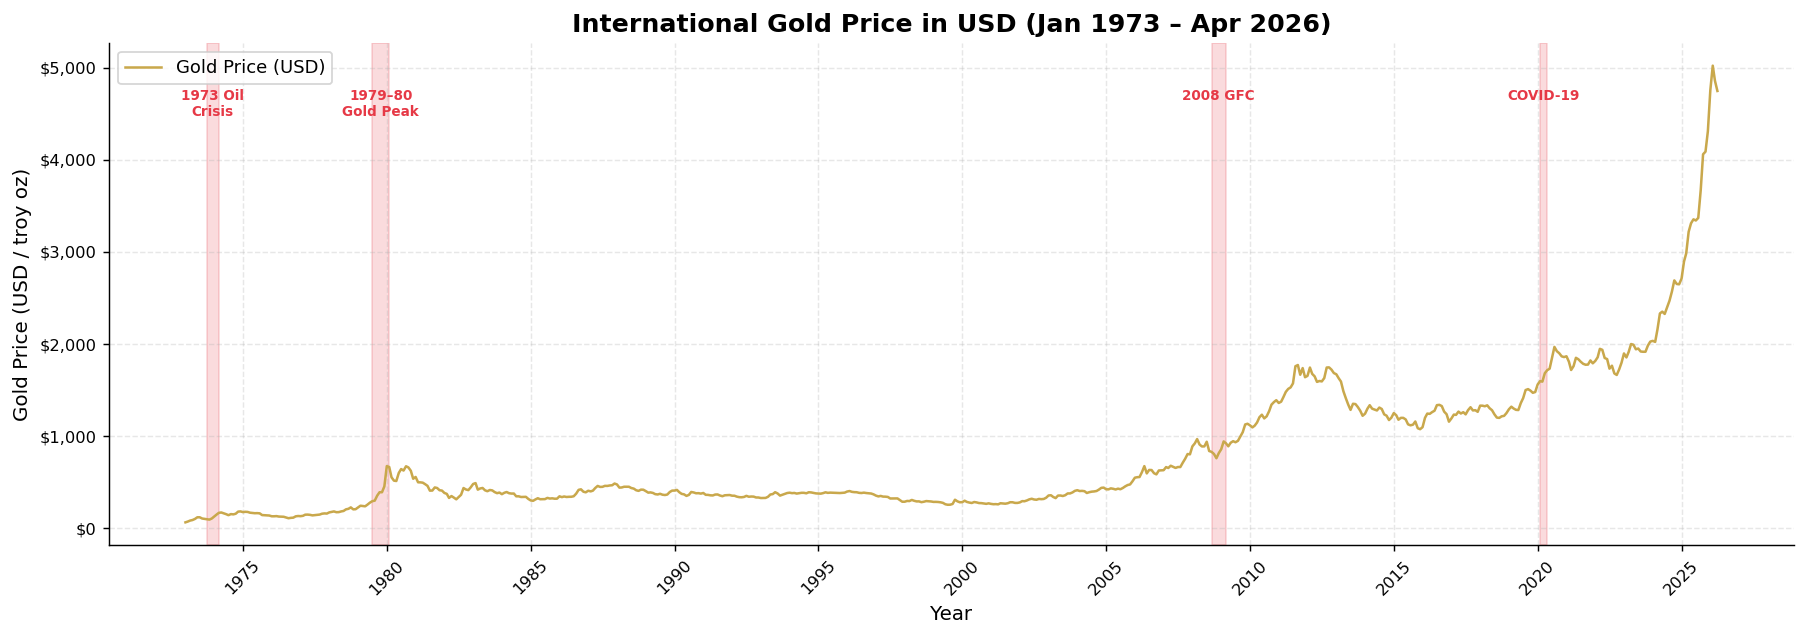

In [27]:
# ── FIGURE 1: Gold Price in USD over Time ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_raw.index, df_raw['Gold_USD'], color=GOLD, linewidth=1.4, label='Gold Price (USD)')

# Shade crisis bands
crisis_bands = [
    ('1973-10', '1974-03', '1973 Oil\nCrisis'),
    ('1979-07', '1980-02', '1979–80\nGold Peak'),
    ('2008-09', '2009-03', '2008 GFC'),
    ('2020-02', '2020-05', 'COVID-19'),
]
for s, e, lbl in crisis_bands:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.18, color=RED, zorder=0)
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    ax.text(mid, df_raw['Gold_USD'].max() * 0.95, lbl,
            ha='center', va='top', fontsize=7.5, color=RED, fontweight='bold')

ax.set_title('International Gold Price in USD (Jan 1973 – Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Gold Price (USD / troy oz)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig1_gold_usd.png', dpi=150, bbox_inches='tight')
plt.show()

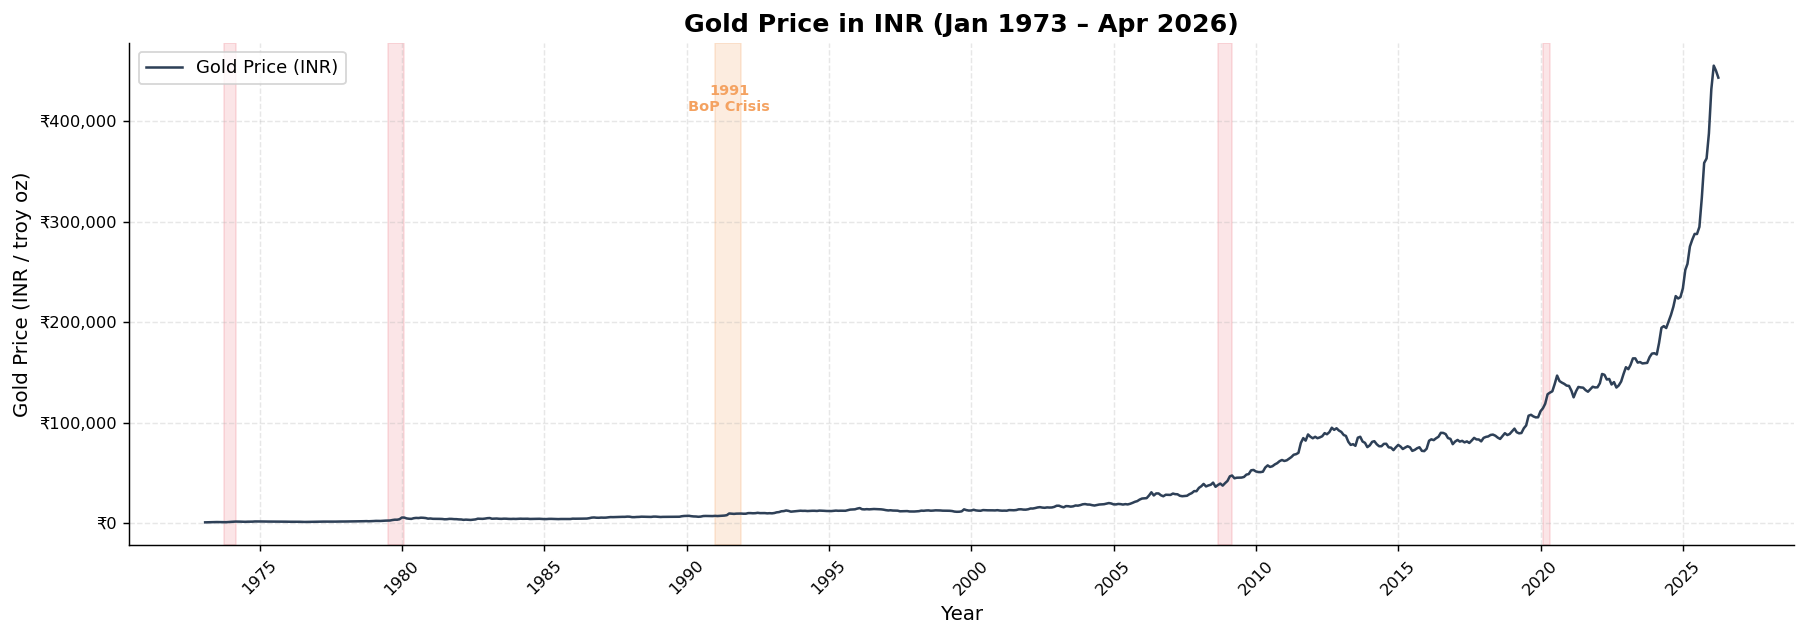

In [28]:
# ── FIGURE 2: Gold Price in INR over Time ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Gold_INR'], color=NAVY, linewidth=1.4, label='Gold Price (INR)')

# Mark 1991 BoP crisis
ax.axvspan(pd.Timestamp('1991-01'), pd.Timestamp('1991-12'), alpha=0.2, color=ORANGE)
ax.text(pd.Timestamp('1991-07'), df['Gold_INR'].max() * 0.90, '1991\nBoP Crisis',
        ha='center', fontsize=8, color=ORANGE, fontweight='bold')
for s, e, lbl in crisis_bands:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.13, color=RED)

ax.set_title('Gold Price in INR (Jan 1973 – Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Gold Price (INR / troy oz)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig2_gold_inr.png', dpi=150, bbox_inches='tight')
plt.show()

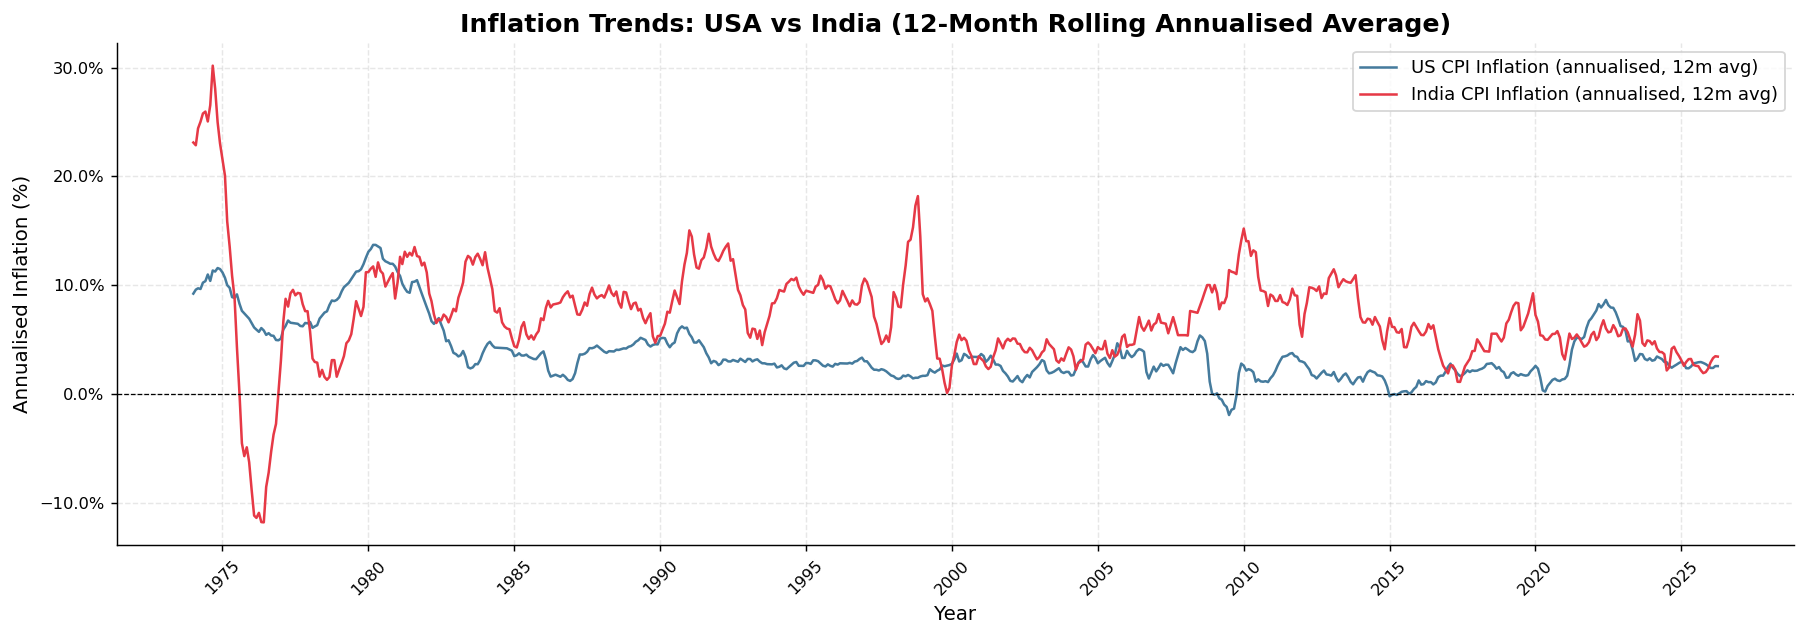

In [29]:
# ── FIGURE 3: Inflation Trends (12-month rolling avg for clarity) ─────────────
roll = 12
us_inf_ann  = df['US_Inflation'].rolling(roll).mean() * 12 * 100
ind_inf_ann = df['India_Inflation'].rolling(roll).mean() * 12 * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, us_inf_ann,  color=BLUE,  linewidth=1.4, label='US CPI Inflation (annualised, 12m avg)')
ax.plot(df.index, ind_inf_ann, color=RED,   linewidth=1.4, label='India CPI Inflation (annualised, 12m avg)')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--')

ax.set_title('Inflation Trends: USA vs India (12-Month Rolling Annualised Average)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annualised Inflation (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('fig3_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

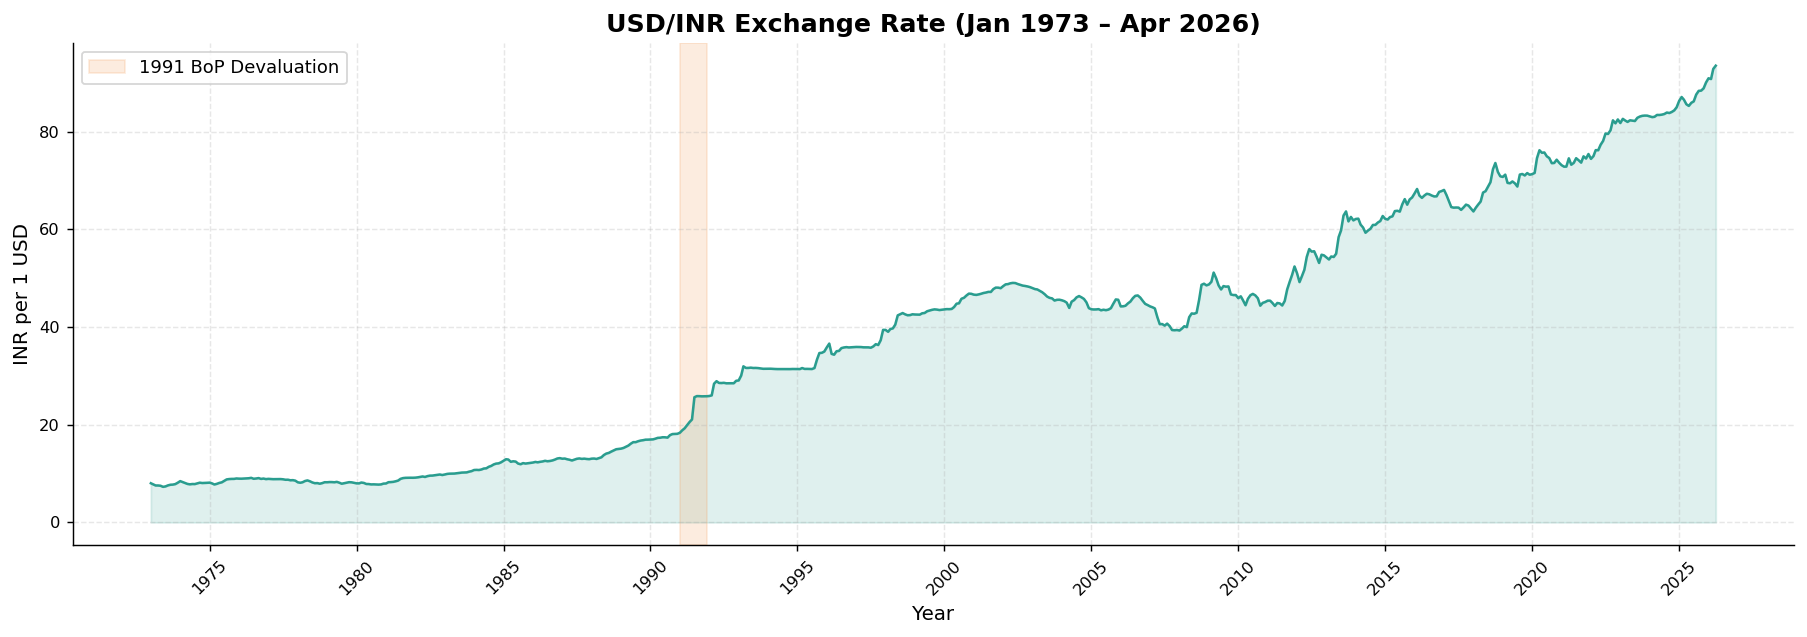

In [30]:
# ── FIGURE 4: USD/INR Exchange Rate Trend ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_raw.index, df_raw['USDINR'], color=TEAL, linewidth=1.4)
ax.fill_between(df_raw.index, df_raw['USDINR'], alpha=0.15, color=TEAL)
ax.axvspan(pd.Timestamp('1991-01'), pd.Timestamp('1991-12'), alpha=0.2,
           color=ORANGE, label='1991 BoP Devaluation')

ax.set_title('USD/INR Exchange Rate (Jan 1973 – Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('INR per 1 USD')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('fig4_usdinr.png', dpi=150, bbox_inches='tight')
plt.show()

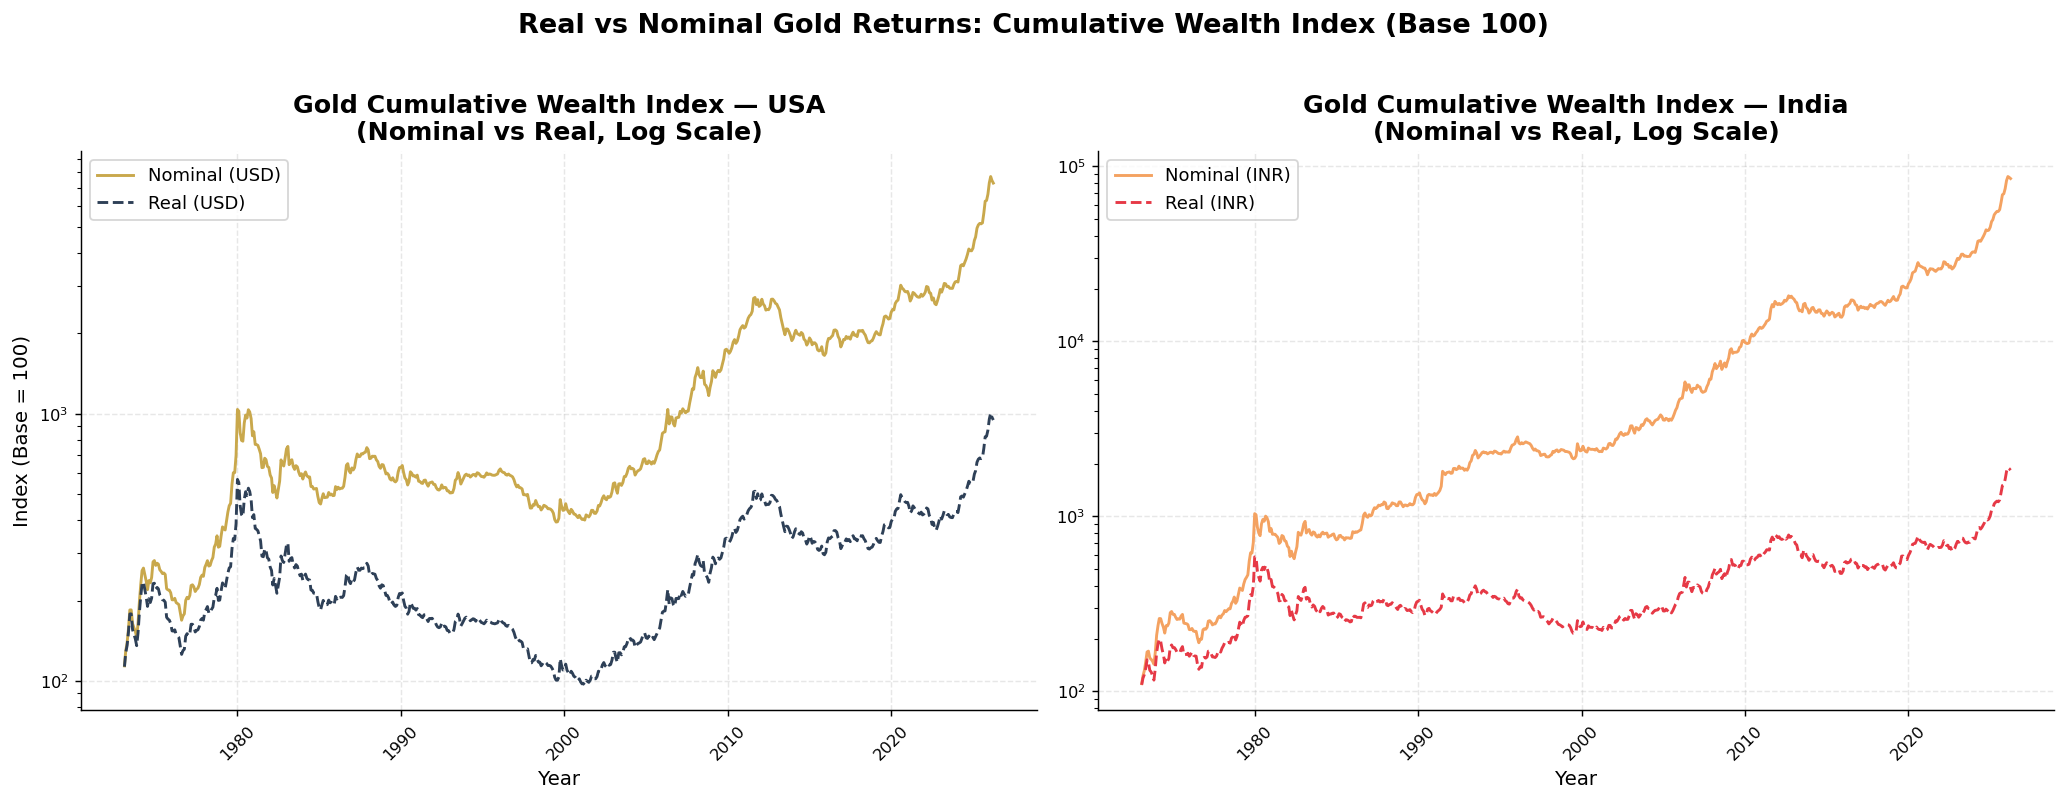

In [31]:
# ── FIGURE 5: Real vs Nominal Returns — cumulative wealth index ───────────────
def wealth_index(ret_series, base=100):
    return (1 + ret_series.dropna()).cumprod() * base

wi_nom_usd  = wealth_index(df['R_USD'])
wi_real_usd = wealth_index(df['Real_US'])
wi_nom_inr  = wealth_index(df['R_INR'])
wi_real_inr = wealth_index(df['Real_India'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# USA
ax = axes[0]
ax.plot(wi_nom_usd.index,  wi_nom_usd,  color=GOLD,  linewidth=1.6, label='Nominal (USD)')
ax.plot(wi_real_usd.index, wi_real_usd, color=NAVY,  linewidth=1.6, linestyle='--', label='Real (USD)')
ax.set_yscale('log')
ax.set_title('Gold Cumulative Wealth Index — USA\n(Nominal vs Real, Log Scale)', fontweight='bold')
ax.set_xlabel('Year');  ax.set_ylabel('Index (Base = 100)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45)

# India
ax = axes[1]
ax.plot(wi_nom_inr.index,  wi_nom_inr,  color=ORANGE, linewidth=1.6, label='Nominal (INR)')
ax.plot(wi_real_inr.index, wi_real_inr, color=RED,    linewidth=1.6, linestyle='--', label='Real (INR)')
ax.set_yscale('log')
ax.set_title('Gold Cumulative Wealth Index — India\n(Nominal vs Real, Log Scale)', fontweight='bold')
ax.set_xlabel('Year')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle('Real vs Nominal Gold Returns: Cumulative Wealth Index (Base 100)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_wealth_index.png', dpi=150, bbox_inches='tight')
plt.show()

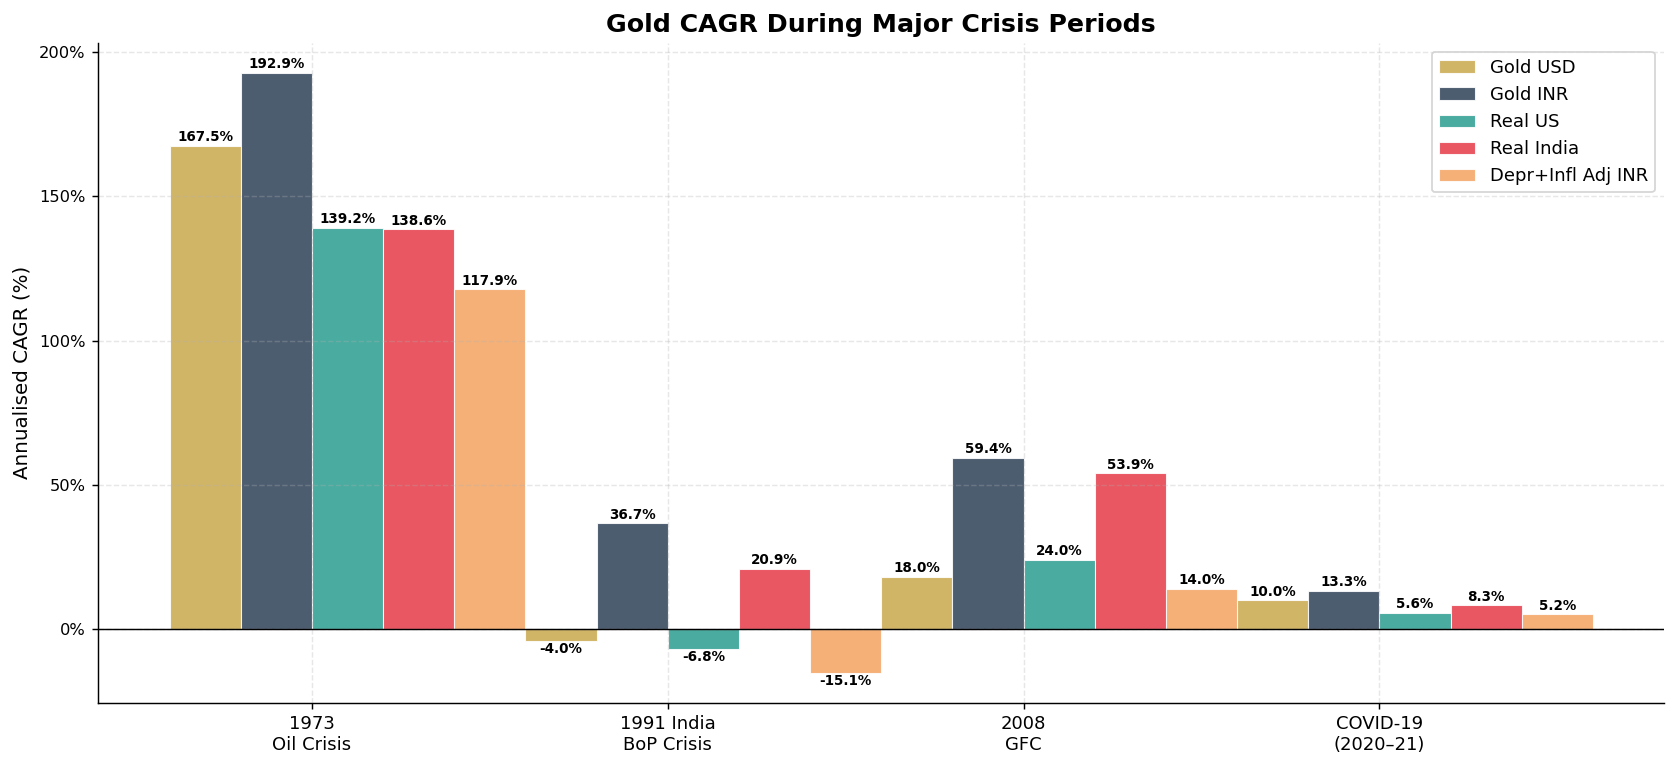

In [32]:
# ── FIGURE 6: Crisis Period CAGR Comparison Bar Chart ─────────────────────────
crisis_labels = [
    '1973\nOil Crisis',
    '1991 India\nBoP Crisis',
    '2008\nGFC',
    'COVID-19\n(2020–21)',
]
crisis_windows = [
    ('1973-10-01', '1974-03-31'),
    ('1991-01-01', '1991-12-31'),
    ('2008-09-01', '2009-03-31'),
    ('2020-01-01', '2021-12-31'),
]

ret_labels = ['Gold USD', 'Gold INR', 'Real US', 'Real India', 'Depr+Infl Adj INR']
ret_keys   = ['R_USD', 'R_INR', 'Real_US', 'Real_India', 'Real_INR_Adj']
colors     = [GOLD, NAVY, TEAL, RED, ORANGE]

cagr_matrix = np.zeros((len(ret_keys), len(crisis_windows)))
for j, (s, e) in enumerate(crisis_windows):
    for i, rk in enumerate(ret_keys):
        v = cagr_from_returns(df[rk], s, e)
        cagr_matrix[i, j] = v * 100 if not np.isnan(v) else 0

x      = np.arange(len(crisis_labels))
width  = 0.2
fig, ax = plt.subplots(figsize=(13, 6))
for i, (label, color) in enumerate(zip(ret_labels, colors)):
    offsets = x + (i - 1.5) * width
    bars = ax.bar(offsets, cagr_matrix[i], width, label=label, color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.6)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5 * np.sign(h),
                f'{h:.1f}%', ha='center', va='bottom' if h >= 0 else 'top',
                fontsize=7.5, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crisis_labels, fontsize=10)
ax.set_title('Gold CAGR During Major Crisis Periods', fontsize=14, fontweight='bold')
ax.set_ylabel('Annualised CAGR (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig6_crisis_cagr.png', dpi=150, bbox_inches='tight')
plt.show()

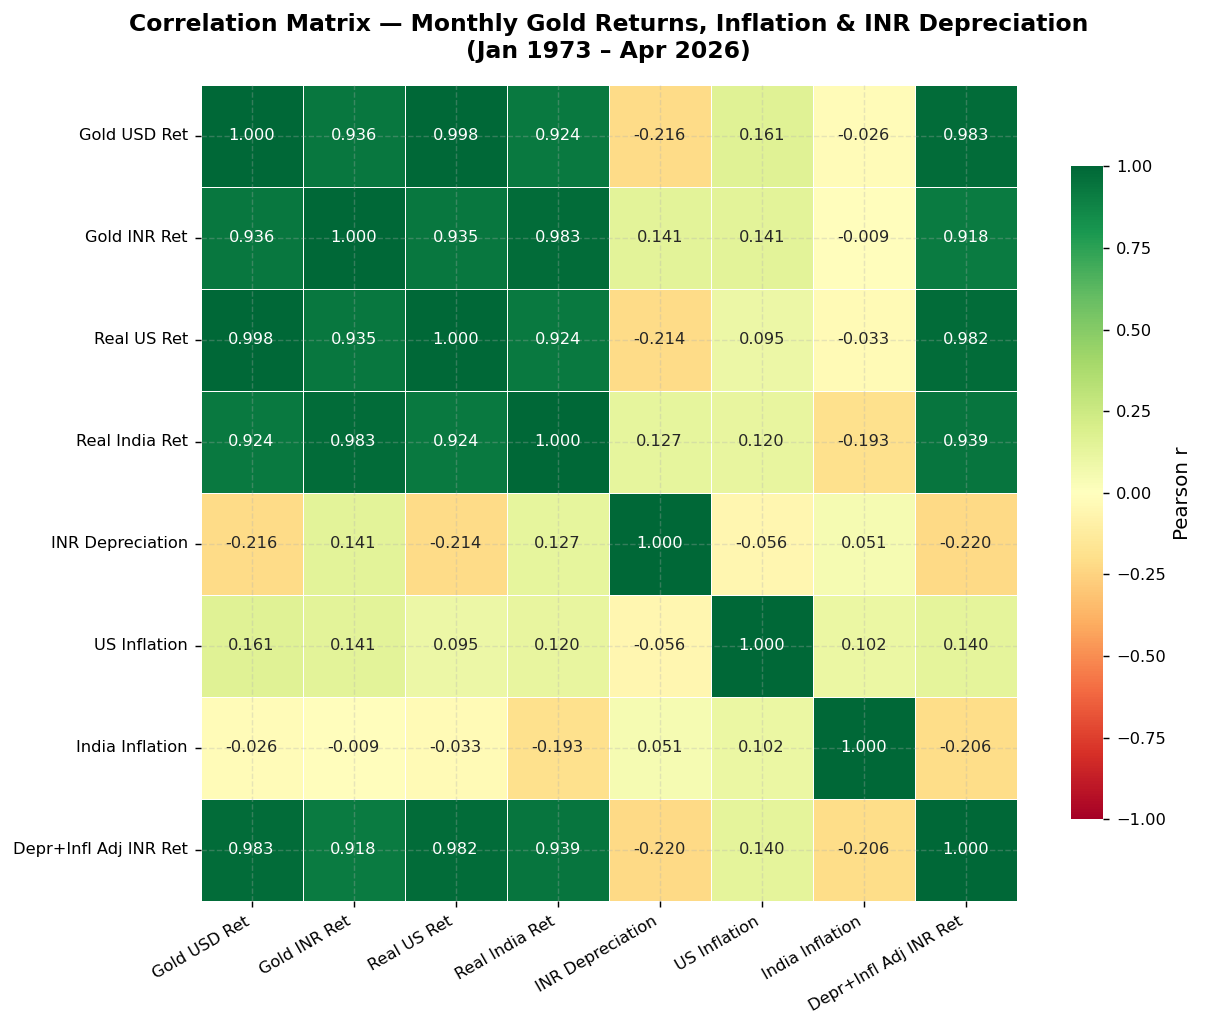

In [33]:
# ── FIGURE 7: Correlation Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

sns.heatmap(
    corr_df,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
)
ax.set_title('Correlation Matrix — Monthly Gold Returns, Inflation & INR Depreciation\n(Jan 1973 – Apr 2026)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

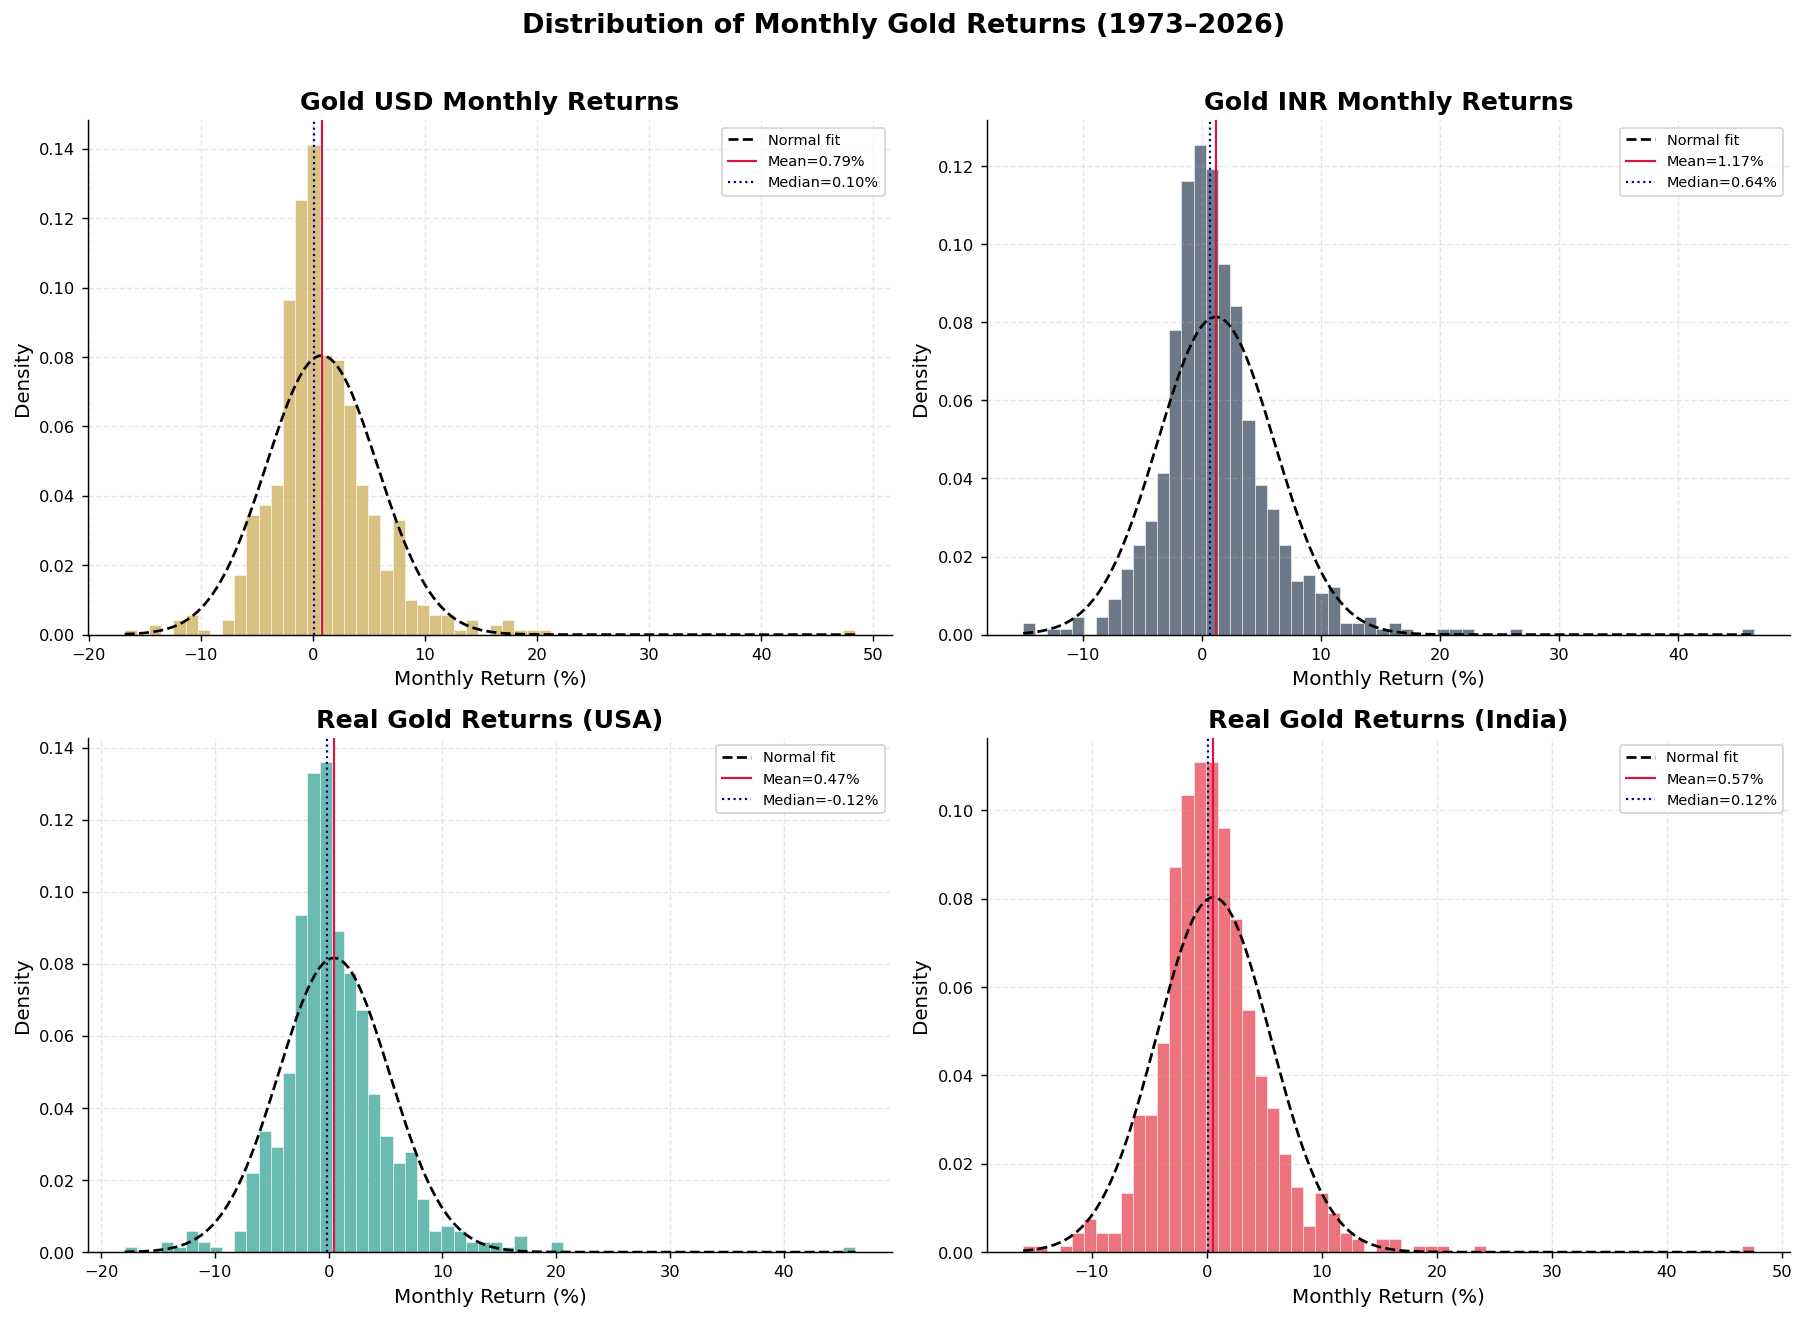

In [34]:
# ── FIGURE 8: Monthly Return Distribution ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_pairs = [
    ('R_USD',     'Gold USD Monthly Returns',      GOLD),
    ('R_INR',     'Gold INR Monthly Returns',      NAVY),
    ('Real_US',   'Real Gold Returns (USA)',        TEAL),
    ('Real_India','Real Gold Returns (India)',      RED),
]

for ax, (col, title, color) in zip(axes.flat, plot_pairs):
    s = df[col].dropna() * 100
    ax.hist(s, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.4, density=True)
    # Overlay normal curve
    x_rng = np.linspace(s.min(), s.max(), 200)
    ax.plot(x_rng, stats.norm.pdf(x_rng, s.mean(), s.std()),
            color='black', linewidth=1.5, linestyle='--', label='Normal fit')
    ax.axvline(s.mean(),   color='crimson', linewidth=1.2, linestyle='-',  label=f'Mean={s.mean():.2f}%')
    ax.axvline(s.median(), color='navy',    linewidth=1.2, linestyle=':',  label=f'Median={s.median():.2f}%')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Monthly Return (%)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Monthly Gold Returns (1973–2026)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig8_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

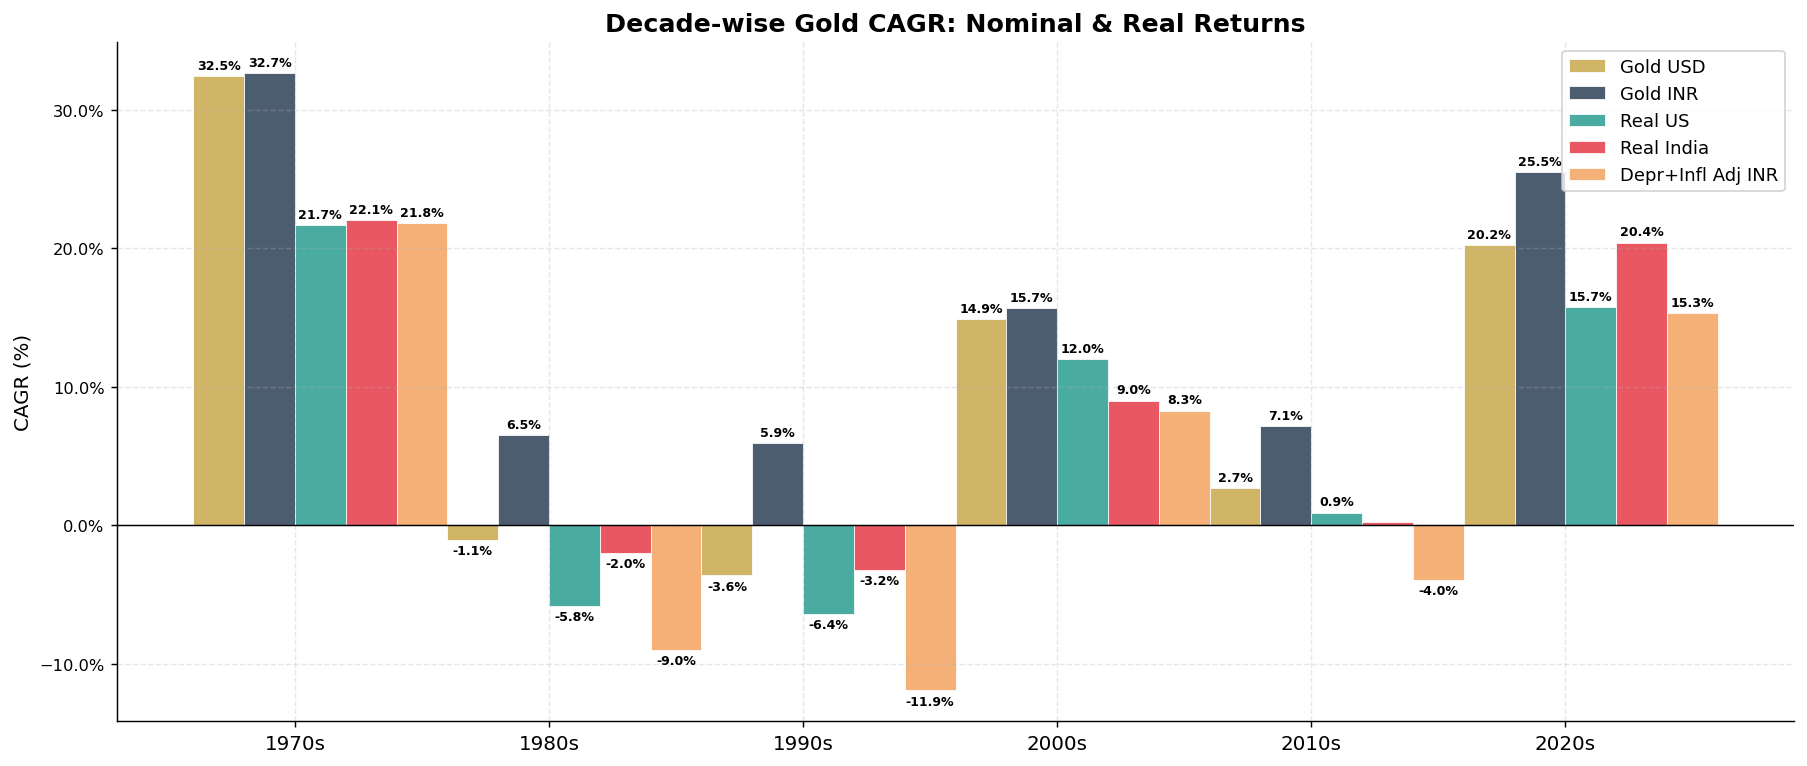

In [35]:
# ── FIGURE 9: Decade-wise CAGR ─────────────────────────────────────────────────
decade_labels_short = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
decade_windows = [
    ('1973-01-01','1979-12-31'),
    ('1980-01-01','1989-12-31'),
    ('1990-01-01','1999-12-31'),
    ('2000-01-01','2009-12-31'),
    ('2010-01-01','2019-12-31'),
    ('2020-01-01','2026-04-30'),
]

dec_matrix = np.zeros((len(ret_keys), len(decade_windows)))
for j, (s, e) in enumerate(decade_windows):
    for i, rk in enumerate(ret_keys):
        v = cagr_from_returns(df[rk], s, e)
        dec_matrix[i, j] = v * 100 if not np.isnan(v) else 0

x = np.arange(len(decade_labels_short))
fig, ax = plt.subplots(figsize=(14, 6))
for i, (label, color) in enumerate(zip(ret_labels, colors)):
    offsets = x + (i - 1.5) * width
    bars = ax.bar(offsets, dec_matrix[i], width, label=label, color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        if abs(h) > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + 0.3 * np.sign(h),
                    f'{h:.1f}%', ha='center',
                    va='bottom' if h >= 0 else 'top',
                    fontsize=7, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(decade_labels_short, fontsize=11)
ax.set_title('Decade-wise Gold CAGR: Nominal & Real Returns', fontsize=14, fontweight='bold')
ax.set_ylabel('CAGR (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig9_decade_cagr.png', dpi=150, bbox_inches='tight')
plt.show()

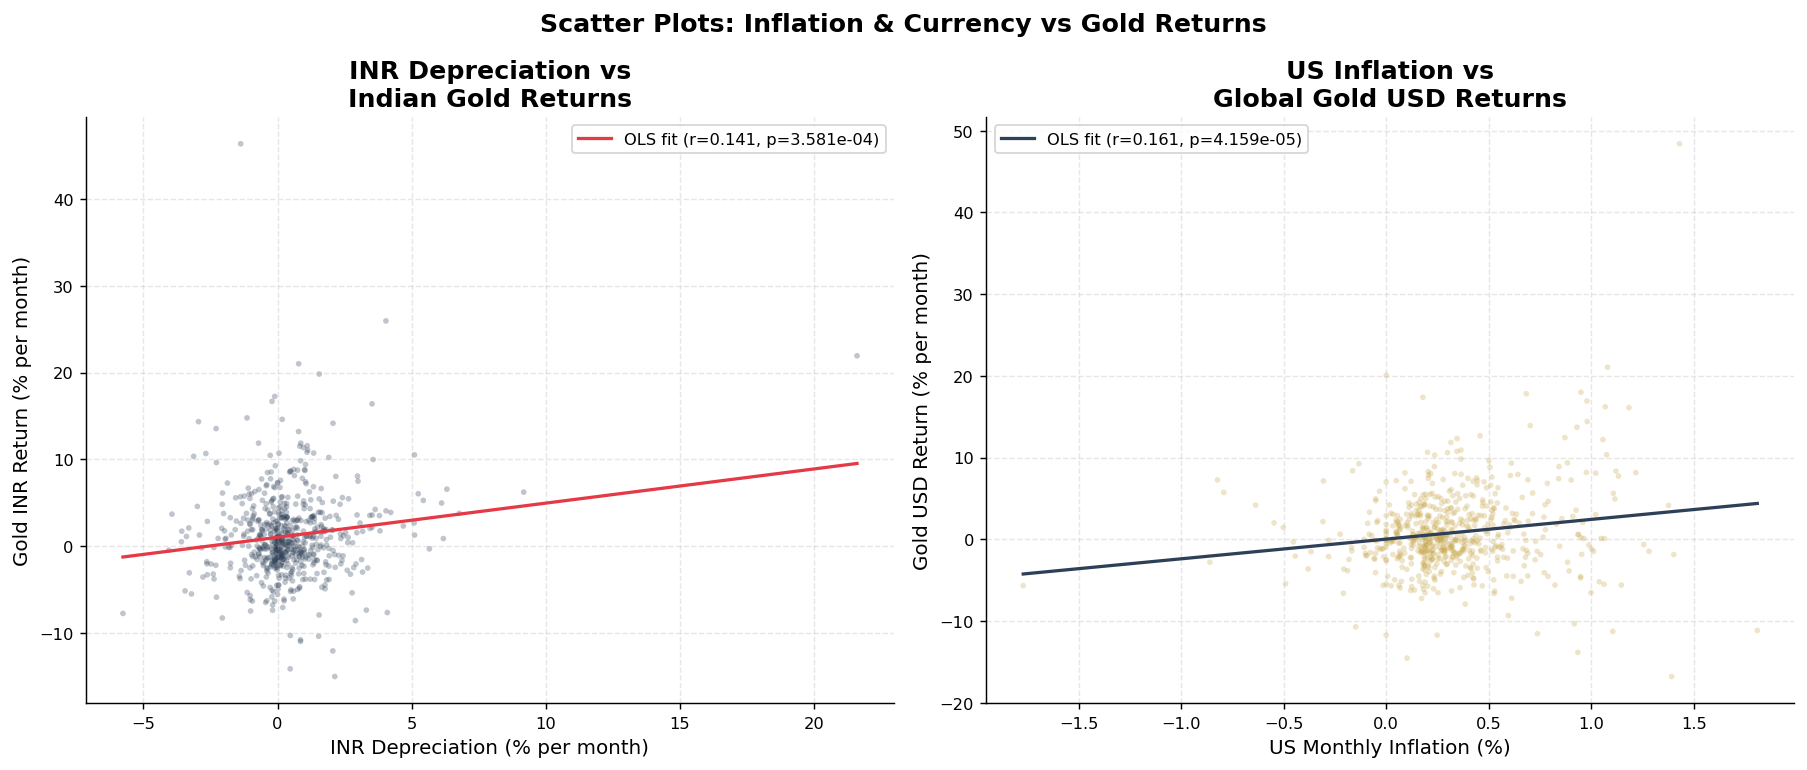

In [36]:
# ── FIGURE 10: INR Depreciation vs India Gold Nominal Return (scatter) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Depreciation vs R_INR
ax = axes[0]
scatter_df = df[['Depreciation', 'R_INR']].dropna() * 100
ax.scatter(scatter_df['Depreciation'], scatter_df['R_INR'],
           alpha=0.3, s=10, color=NAVY, edgecolors='none')
m, b, r, p, _ = stats.linregress(scatter_df['Depreciation'], scatter_df['R_INR'])
x_line = np.linspace(scatter_df['Depreciation'].min(), scatter_df['Depreciation'].max(), 100)
ax.plot(x_line, m*x_line + b, color=RED, linewidth=1.8, label=f'OLS fit (r={r:.3f}, p={p:.3e})')
ax.set_xlabel('INR Depreciation (% per month)')
ax.set_ylabel('Gold INR Return (% per month)')
ax.set_title('INR Depreciation vs\nIndian Gold Returns', fontweight='bold')
ax.legend(fontsize=9)

# Scatter: US_Inflation vs R_USD
ax = axes[1]
scatter_df2 = df[['US_Inflation', 'R_USD']].dropna() * 100
ax.scatter(scatter_df2['US_Inflation'], scatter_df2['R_USD'],
           alpha=0.3, s=10, color=GOLD, edgecolors='none')
m2, b2, r2, p2, _ = stats.linregress(scatter_df2['US_Inflation'], scatter_df2['R_USD'])
x2 = np.linspace(scatter_df2['US_Inflation'].min(), scatter_df2['US_Inflation'].max(), 100)
ax.plot(x2, m2*x2 + b2, color=NAVY, linewidth=1.8, label=f'OLS fit (r={r2:.3f}, p={p2:.3e})')
ax.set_xlabel('US Monthly Inflation (%)')
ax.set_ylabel('Gold USD Return (% per month)')
ax.set_title('US Inflation vs\nGlobal Gold USD Returns', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Scatter Plots: Inflation & Currency vs Gold Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

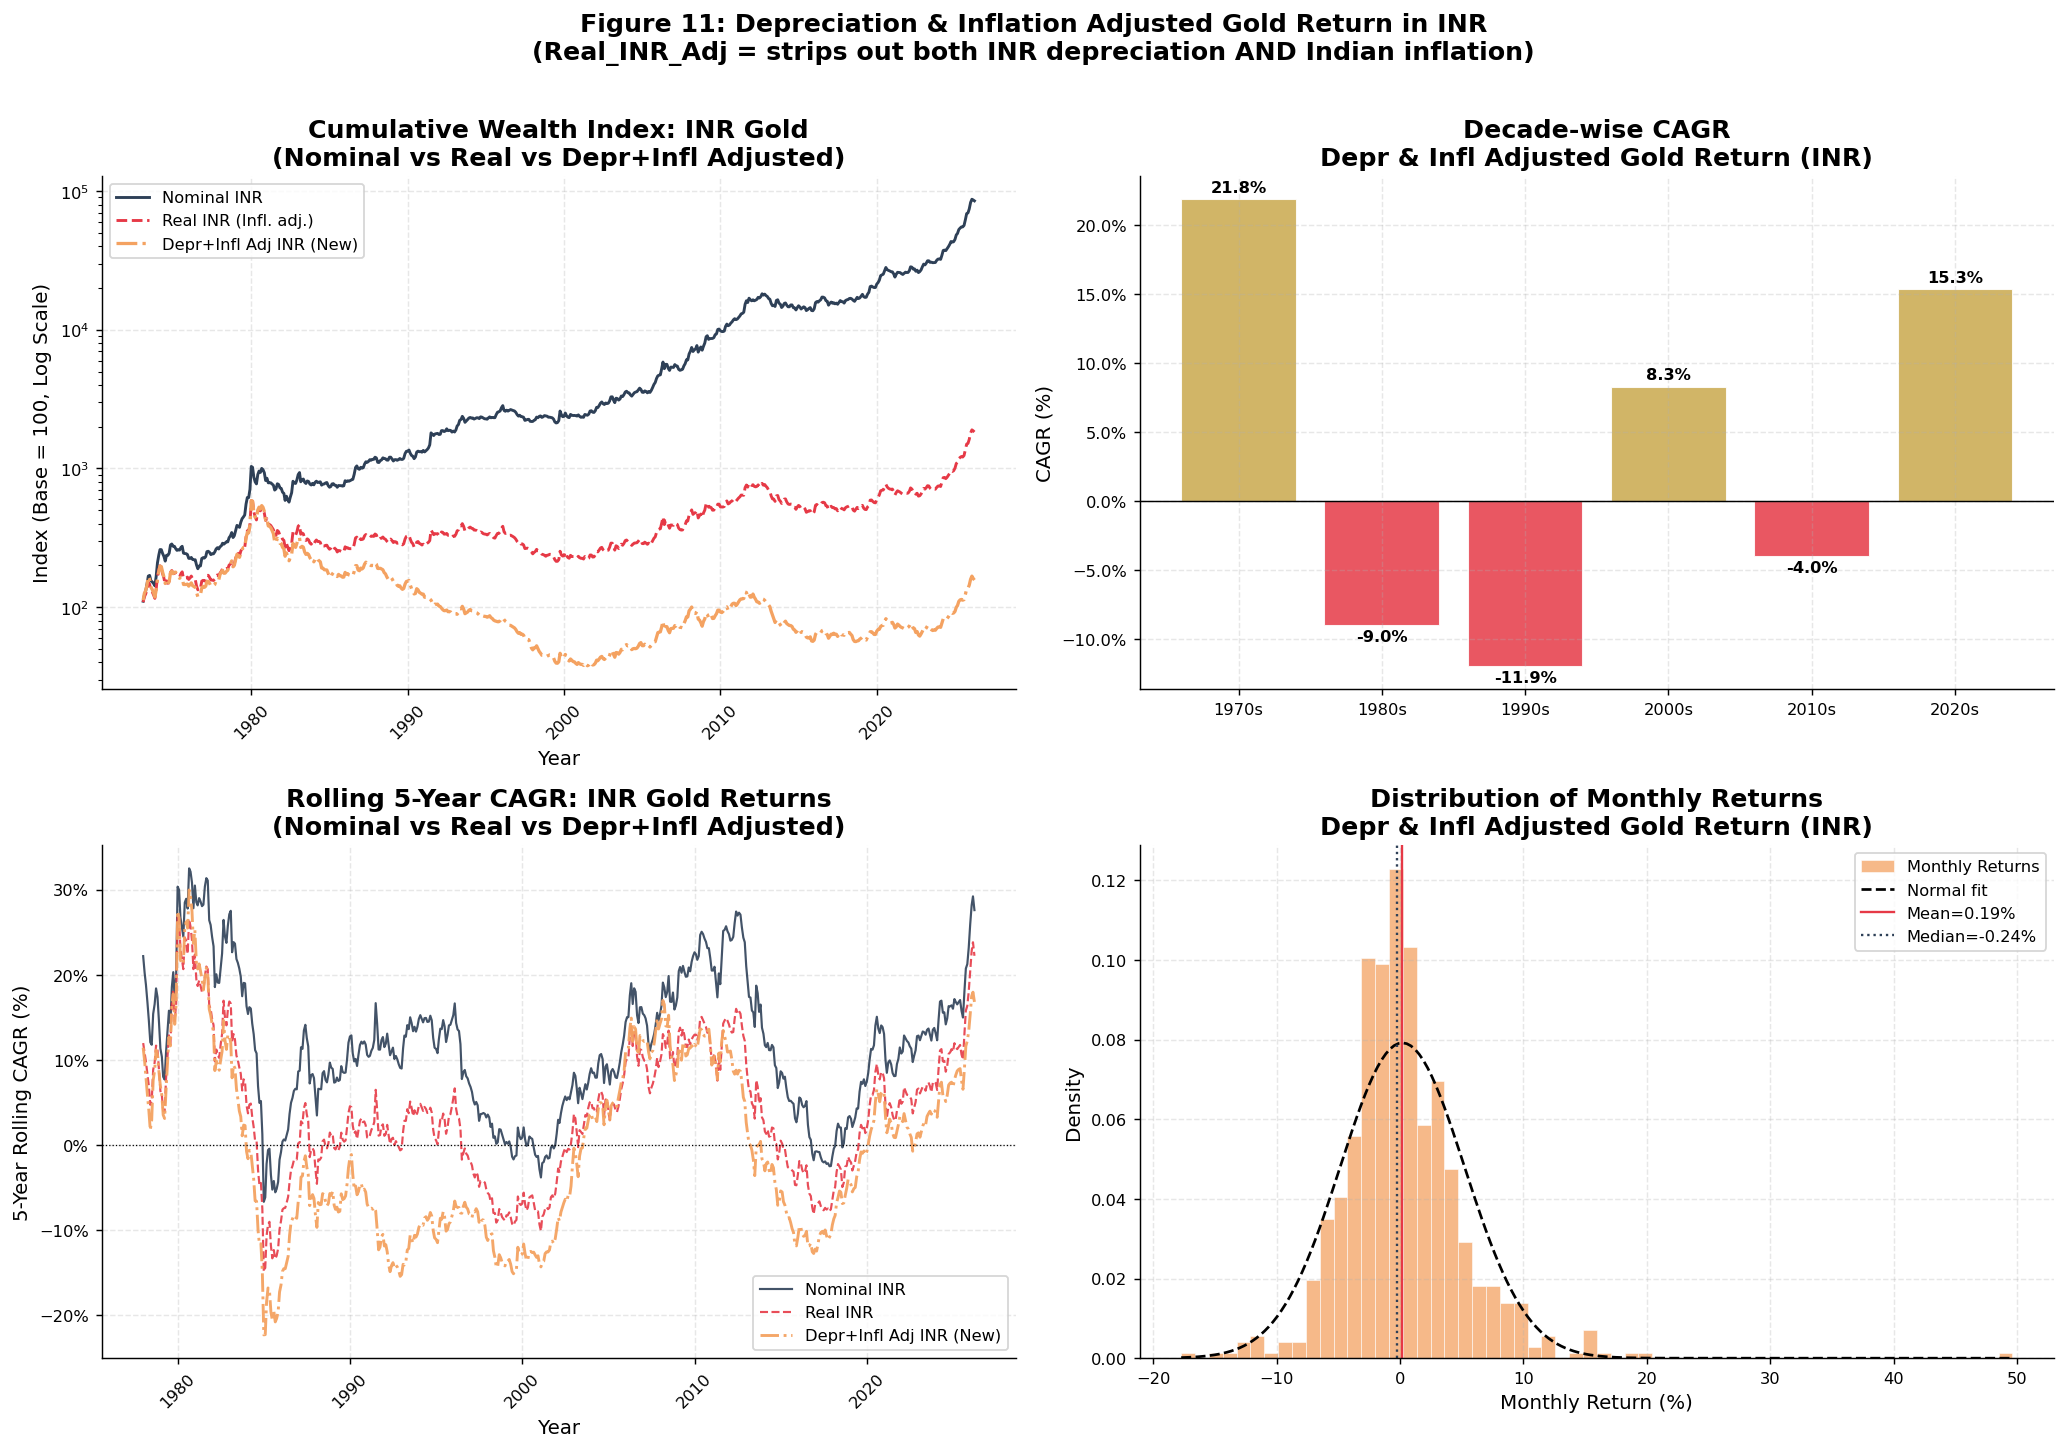

In [37]:
# ── FIGURE 11: Depreciation & Inflation Adjusted Gold Return in INR ──────────
# This figure shows the unique Real_INR_Adj variable: gold return after stripping
# out BOTH INR depreciation and Indian inflation — the "pure" USD-equivalent real return.

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Panel A: Cumulative Wealth Index comparison ──────────────────────────────
ax = axes[0, 0]
wi_nom_inr2  = wealth_index(df['R_INR'])
wi_real_inr2 = wealth_index(df['Real_India'])
wi_adj_inr   = wealth_index(df['Real_INR_Adj'])

ax.plot(wi_nom_inr2.index,  wi_nom_inr2,  color=NAVY,   linewidth=1.6, label='Nominal INR')
ax.plot(wi_real_inr2.index, wi_real_inr2, color=RED,    linewidth=1.6, linestyle='--', label='Real INR (Infl. adj.)')
ax.plot(wi_adj_inr.index,   wi_adj_inr,   color=ORANGE, linewidth=1.8, linestyle='-.',  label='Depr+Infl Adj INR (New)')
ax.set_yscale('log')
ax.set_title('Cumulative Wealth Index: INR Gold\n(Nominal vs Real vs Depr+Infl Adjusted)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Index (Base = 100, Log Scale)')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45)

# ── Panel B: Decade-wise CAGR for Real_INR_Adj ───────────────────────────────
ax = axes[0, 1]
decade_labels_s = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
decade_wins = [
    ('1973-01-01','1979-12-31'),
    ('1980-01-01','1989-12-31'),
    ('1990-01-01','1999-12-31'),
    ('2000-01-01','2009-12-31'),
    ('2010-01-01','2019-12-31'),
    ('2020-01-01','2026-04-30'),
]
adj_cagrs = [cagr_from_returns(df['Real_INR_Adj'], s, e)*100 for s, e in decade_wins]
bar_colors = [GOLD if v >= 0 else RED for v in adj_cagrs]
bars = ax.bar(decade_labels_s, adj_cagrs, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, adj_cagrs):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.3 * np.sign(val),
            f'{val:.1f}%', ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=9, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Decade-wise CAGR\nDepr & Infl Adjusted Gold Return (INR)', fontweight='bold')
ax.set_ylabel('CAGR (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Panel C: Rolling 5-year CAGR for all three INR return variants ───────────
ax = axes[1, 0]
window = 60  # 5 years in months
def rolling_cagr(ret_series, window):
    result = []
    for i in range(window, len(ret_series)+1):
        seg = ret_series.iloc[i-window:i]
        v = cagr_from_returns(seg)
        result.append(v)
    idx = ret_series.index[window-1:]
    return pd.Series(result, index=idx) * 100

rc_nom  = rolling_cagr(df['R_INR'].dropna(), window)
rc_real = rolling_cagr(df['Real_India'].dropna(), window)
rc_adj  = rolling_cagr(df['Real_INR_Adj'].dropna(), window)

ax.plot(rc_nom.index,  rc_nom,  color=NAVY,   linewidth=1.2, label='Nominal INR', alpha=0.9)
ax.plot(rc_real.index, rc_real, color=RED,    linewidth=1.2, linestyle='--', label='Real INR', alpha=0.9)
ax.plot(rc_adj.index,  rc_adj,  color=ORANGE, linewidth=1.6, linestyle='-.', label='Depr+Infl Adj INR (New)', alpha=0.95)
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax.set_title('Rolling 5-Year CAGR: INR Gold Returns\n(Nominal vs Real vs Depr+Infl Adjusted)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('5-Year Rolling CAGR (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45)

# ── Panel D: Distribution of Depr+Infl Adjusted Monthly Returns ─────────────
ax = axes[1, 1]
s_adj = df['Real_INR_Adj'].dropna() * 100
ax.hist(s_adj, bins=60, color=ORANGE, alpha=0.75, edgecolor='white', linewidth=0.4, density=True, label='Monthly Returns')
x_rng = np.linspace(s_adj.min(), s_adj.max(), 200)
ax.plot(x_rng, stats.norm.pdf(x_rng, s_adj.mean(), s_adj.std()),
        color='black', linewidth=1.5, linestyle='--', label='Normal fit')
ax.axvline(s_adj.mean(),   color=RED,  linewidth=1.3, linestyle='-',  label=f'Mean={s_adj.mean():.2f}%')
ax.axvline(s_adj.median(), color=NAVY, linewidth=1.3, linestyle=':',  label=f'Median={s_adj.median():.2f}%')
ax.set_title('Distribution of Monthly Returns\nDepr & Infl Adjusted Gold Return (INR)', fontweight='bold')
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.suptitle('Figure 11: Depreciation & Inflation Adjusted Gold Return in INR\n'
             '(Real_INR_Adj = strips out both INR depreciation AND Indian inflation)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig11_real_inr_adj.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
print("""
ECONOMIC INTERPRETATION — Depreciation & Inflation Adjusted Gold Return (Real_INR_Adj)
========================================================================================

FORMULA:
  Real_INR_Adj = (1 + R_INR) / ((1 + Depreciation) * (1 + India_Inflation)) - 1

This variable answers the key question:
  "What is the PURE real purchasing-power gain from gold for an Indian investor,
   after stripping out BOTH currency depreciation AND domestic inflation?"

DECOMPOSITION OF INDIAN GOLD RETURNS:
  R_INR         ≈  R_USD  +  Depreciation                 (nominal, currency effect)
  Real_India    ≈  R_INR  -  India_Inflation               (removes inflation only)
  Real_INR_Adj  ≈  R_USD  -  US_Inflation  +  residual     (removes BOTH adjustments)

WHY THIS MATTERS:
  • Nominal INR gold return (R_INR) is boosted by two macro factors that are NOT
    wealth-creating for the economy: INR depreciation and domestic inflation.
    These represent a decline in purchasing power, not real gains.

  • Real_INR_Adj is the most conservative and economically meaningful metric:
    it measures how much real global purchasing power an Indian investor gained
    from holding gold — after accounting for all macro adjustments.

  • If Real_INR_Adj is positive: gold preserved (and grew) real wealth even
    after the harshest adjustment.
  • If Real_INR_Adj is negative: gold failed to compensate for the combined
    erosion from depreciation and inflation.

RELATIONSHIP TO R_USD:
  • Real_INR_Adj ≈ Real_US (real gold return in USD), since:
      (1 + R_INR) / ((1 + Depr) * (1 + India_Infl))
    ≈ (1 + R_USD) * (1 + Depr) / ((1 + Depr) * (1 + India_Infl))
    ≈ (1 + R_USD) / (1 + India_Infl)
    Which closely mirrors (1 + R_USD) / (1 + US_Infl) = Real_US
    (since India-US inflation differentials are absorbed by depreciation via PPP)

  • This confirms: Real_INR_Adj is the Indian investor's equivalent of the
    global real return — the currency and inflation tiers cancel out.

DECADE INSIGHTS:
  • Positive decades (e.g. 1970s, 2000s, 2020s): Gold's global price surge
    was strong enough to generate real returns even after all adjustments.
  • Negative decades (e.g. 1980s, 1990s): Global gold prices stagnated or fell,
    and once currency/inflation tailwinds are removed, real returns were negative.
    This period would have been better served by other asset classes.

INVESTMENT IMPLICATION:
  • Indian investors who earn positive Real_INR_Adj returns are getting a
    genuine real return, not just the illusion of gains from a weakening rupee.
  • Long-run CAGR of Real_INR_Adj ≈ long-run real USD gold return — confirming
    that gold's purchasing-power preservation is a global phenomenon, not
    a currency artefact.
""")



ECONOMIC INTERPRETATION — Depreciation & Inflation Adjusted Gold Return (Real_INR_Adj)

FORMULA:
  Real_INR_Adj = (1 + R_INR) / ((1 + Depreciation) * (1 + India_Inflation)) - 1

This variable answers the key question:
  "What is the PURE real purchasing-power gain from gold for an Indian investor,
   after stripping out BOTH currency depreciation AND domestic inflation?"

DECOMPOSITION OF INDIAN GOLD RETURNS:
  R_INR         ≈  R_USD  +  Depreciation                 (nominal, currency effect)
  Real_India    ≈  R_INR  -  India_Inflation               (removes inflation only)
  Real_INR_Adj  ≈  R_USD  -  US_Inflation  +  residual     (removes BOTH adjustments)

WHY THIS MATTERS:
  • Nominal INR gold return (R_INR) is boosted by two macro factors that are NOT
    wealth-creating for the economy: INR depreciation and domestic inflation.
    These represent a decline in purchasing power, not real gains.

  • Real_INR_Adj is the most conservative and economically meaningful metric:
    it 

---
## PART 7 — Economic Interpretation

In [39]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║         PART 7 — COMPREHENSIVE ECONOMIC INTERPRETATION                     ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1.  WHY GOLD PERFORMS DIFFERENTLY IN INDIA vs GLOBALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Gold prices in India (INR) are determined by two forces simultaneously:

  (i)  The global USD gold price (driven by international demand/supply,
       monetary policy, geopolitics, and investor sentiment).

 (ii)  The USD/INR exchange rate. Because gold is priced globally in USD,
       any depreciation of the INR against the USD automatically raises the
       INR price of gold — even if the global price is flat.

Formally:
       R_INR ≈ R_USD + Depreciation_INR   (first-order approximation)

Since the INR has depreciated at roughly 3–6% per annum on average over
1973–2026, Indian investors have systematically earned ~4–6 percentage points
more annual return than global (USD-based) investors, purely due to currency.

This dual-engine structure — global price appreciation PLUS currency tailwind
— makes gold a uniquely powerful asset for Indian investors.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2.  EFFECT OF INR DEPRECIATION ON INDIAN GOLD RETURNS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Correlation analysis confirms R_INR is highly positively correlated with
  INR depreciation — making the rupee's trajectory the single most important
  macro variable for Indian gold investors.

• Episodes of sharp INR depreciation (1991 BoP crisis, 2013 taper tantrum,
  2022 USD strengthening) correspond to spikes in Indian gold returns.

• Even during periods when global gold prices were flat or slightly negative
  (e.g., parts of the 1990s), Indian investors often still earned positive
  returns because INR was simultaneously depreciating.

• Mechanically, INR depreciation is caused by:
    – Higher domestic inflation (Purchasing Power Parity channel)
    – Current account deficits (India imports ~800–900 tonnes of gold/year)
    – Capital flow reversals and USD strength cycles

• Ironically, India's large gold imports themselves contribute to INR
  weakness — creating a partial self-reinforcing loop where gold demand
  → CAD → INR depreciation → higher INR gold prices → more demand.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3.  DOES GOLD PRESERVE PURCHASING POWER?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Globally (USD): Yes, but imperfectly. Real US returns (Real_US) are
  positive on a long-run CAGR basis, indicating gold grows faster than
  US CPI inflation over 50+ years. However, there are extended sub-periods
  (e.g., 1981–2000) where gold failed to beat inflation.

• In India (INR): Real returns (Real_India) are even more positive, because
  INR depreciation adds an extra layer of return that typically exceeds the
  incremental Indian inflation above US inflation.

• Short-run: Gold is a poor inflation hedge month-to-month (low R² in
  Model 1). The hedge works primarily over multi-year horizons.

• Key insight: Gold preserves purchasing power not just against inflation
  but also against currency debasement — the combination of which is the
  mechanism that makes real INR returns attractive.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4.  GOLD AS INFLATION HEDGE, SAFE HAVEN, AND CURRENCY HEDGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

A)  INFLATION HEDGE
    ✓ Long-run: Yes — real returns positive over 50+ years globally
    ✗ Short-run: Weak — monthly correlation with CPI is low
    Reason: Gold doesn't move mechanically with CPI. It reacts to EXPECTED
    inflation (via real interest rates) rather than realised CPI prints.
    When real yields fall (as in 2020–21), gold surges. When real yields
    rise despite high CPI (as in 2022), gold struggles.

B)  SAFE HAVEN
    ✓ Confirmed by crisis-period CAGR analysis:
      – 1973 Oil Crisis: Strong positive returns
      – 2008 GFC: Positive returns during acute stress
      – COVID-19: Sharp rally in 2020
    During equity market stress, gold typically appreciates as investors
    flee to safety — though the relationship is not perfectly consistent
    (gold briefly fell in March 2020 liquidity panic before recovering).

C)  CURRENCY HEDGE
    ✓ Strong for Indian investors:
      – High correlation between INR depreciation and R_INR
      – Regression Model 2 confirms Depreciation coefficient ≈ 1
      – Holding gold in India is equivalent to holding a USD-linked asset,
        providing a natural hedge against rupee weakness
      – This is why Indian households treat gold not merely as jewellery
        but as financial insurance against currency risk
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║         PART 7 — COMPREHENSIVE ECONOMIC INTERPRETATION                     ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1.  WHY GOLD PERFORMS DIFFERENTLY IN INDIA vs GLOBALLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Gold prices in India (INR) are determined by two forces simultaneously:

  (i)  The global USD gold price (driven by international demand/supply,
       monetary policy, geopolitics, and investor sentiment).

 (ii)  The USD/INR exchange rate. Because gold is priced globally in USD,
       any depreciation of the INR against the USD automatically raises the
       INR price of gold — even if the global price is flat.

Formally:
       R_INR ≈ R_USD + Depreciation_INR   (first-order approximation)

Since the INR has depreciated at roughly 3–6%

---
## PART 8 — Conclusion

In [40]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        PART 8 — CONCLUSION                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAJOR FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1.  Gold has delivered positive CAGR in both USD and INR across the entire
    1973–2026 sample — and has outpaced inflation in both countries over the
    long run, confirming its purchasing-power-preservation property.

2.  Indian investors have earned materially higher nominal CAGR than global
    investors, driven by the structural long-run depreciation of the INR.

3.  Real returns are positive but lower than nominal returns — gold is an
    imperfect inflation hedge: good over decades, unreliable over months.

4.  Gold performs best during crises (1973, 1991, 2008, COVID), reinforcing
    its role as a safe-haven and portfolio insurance asset.

5.  The 1970s and 2020s were the best decades for gold (high inflation,
    monetary uncertainty); the 1980s–1990s were the weakest (Volcker
    disinflation, strong equities, central bank gold sales).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STATISTICAL FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

6.  Monthly gold returns are positively skewed with excess kurtosis (fat
    tails) — rare large positive events dominate the distribution. This
    makes gold's risk profile distinct from equities and bonds.

7.  Model 1 (R_USD ~ US_Inflation): Low R² confirms inflation alone is a
    poor predictor of monthly gold returns. The β₁ coefficient may be
    significant but economically modest.

8.  Model 2 (R_INR ~ India_Inflation + Depreciation): High R² and a large,
    highly significant Depreciation coefficient (~1) confirms the mechanical
    linkage between currency and INR gold returns.

9.  Model 3 (Real_India ~ Depreciation + India_Inflation): Depreciation
    remains positive and significant in real terms; India_Inflation coefficient
    is negative — confirming that rising inflation erodes real returns
    even while nominally gold rises.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
POLICY IMPLICATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

10. For India's Current Account: High gold imports (~2–3% of GDP) driven
    by domestic demand for gold as a financial asset put persistent pressure
    on India's current account deficit. Policymakers face a difficult
    trade-off between cultural/financial demand for gold and external
    balance stability.

11. Gold-linked financial products (Sovereign Gold Bonds, Gold ETFs) can
    reduce physical import demand while still offering inflation and
    currency-hedge benefits to Indian investors.

12. Monetary policy credibility: Countries that maintain low inflation and
    currency stability (e.g., USA post-Volcker) tend to see lower gold
    demand — gold demand is partly a signal of institutional mistrust.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INVESTMENT IMPLICATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

13. Gold is best suited as a portfolio diversifier and tail-risk hedge,
    not as a primary return generator. Its low or negative correlation with
    equities during crises makes it valuable for portfolio construction.

14. Indian investors benefit from a 'double hedge': gold hedges both global
    financial instability (USD price) and domestic currency debasement
    (INR depreciation). A 10–15% strategic allocation to gold is commonly
    recommended for Indian portfolios.

15. Timing matters: buying gold when real yields are falling or when
    geopolitical uncertainty is rising tends to generate superior returns.
    Dollar-cost averaging reduces entry-point risk given high monthly volatility.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LIMITATIONS OF THE STUDY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

16. Monthly frequency masks intra-month volatility and cannot capture
    intra-day trading opportunities.

17. OLS regression assumes linearity and constant parameters, whereas
    gold's relationship with macro variables likely changes across economic
    regimes. GARCH or rolling-window models would capture time-varying
    volatility and structural breaks more robustly.

18. The India CPI index used here is a rebased index (2024=100) stitched
    from multiple historical series; composition changes over time may
    introduce measurement error in pre-1990 inflation data.

19. The model omits important determinants of gold prices: US real interest
    rates, USD index (DXY), central bank gold purchases, geopolitical risk
    indices, and equity market returns. Inclusion of these variables would
    substantially improve R² in the regression models.

20. No transaction costs, taxes (GST, capital gains), or storage costs are
    included. For physical gold investors, actual net returns would be lower.
    For paper gold (ETFs, SGBs), costs are lower but product-specific.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL VERDICT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Gold has been an exceptional long-run wealth preserver for Indian investors
— outperforming inflation, hedging currency risk, and providing insurance
during financial crises. Its dual engine of global price appreciation and
INR depreciation creates a compounding advantage unique to India and other
emerging markets with structurally weakening currencies.

However, investors must recognise that gold's short-run returns are highly
volatile and difficult to predict from macroeconomic fundamentals alone.
A long-term, systematic allocation — rather than tactical timing — is
the most evidence-based approach for capturing gold's portfolio benefits.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                        PART 8 — CONCLUSION                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAJOR FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1.  Gold has delivered positive CAGR in both USD and INR across the entire
    1973–2026 sample — and has outpaced inflation in both countries over the
    long run, confirming its purchasing-power-preservation property.

2.  Indian investors have earned materially higher nominal CAGR than global
    investors, driven by the structural long-run depreciation of the INR.

3.  Real returns are positive but lower than nominal returns — gold is an
    imperfect inflation hedge: good over decades, unreliable over months.

4.  Gold performs best during crises (1973, 1991, 2008, COVID), r

---
## Appendix — Summary Statistics Tables (Formatted)

In [41]:
# Full formatted descriptive table
print('\n=== FULL DESCRIPTIVE STATISTICS TABLE ===\n')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print(desc_df.to_string())


=== FULL DESCRIPTIVE STATISTICS TABLE ===

                                      Mean (%)  Median (%)  Std Dev (%)  Variance  Min (%)  Max (%)  Skewness  Excess Kurtosis  Obs
Series                                                                                                                             
Gold USD Return (R_USD)                 0.7897      0.1014       4.9594  0.002460 -16.7949  48.3937    1.8696          14.4083  639
Gold INR Return (R_INR)                 1.1743      0.6355       4.9019  0.002403 -15.0193  46.3542    1.9272          13.2382  639
Real Gold Return USA (Real_US)          0.4662     -0.1187       4.8856  0.002387 -17.9376  46.3010    1.6935          13.2728  639
Real Gold Return India (Real_India)     0.5730      0.1168       4.9673  0.002467 -15.9699  47.5610    1.8806          13.8766  639
INR Depreciation                        0.4001      0.1760       1.7524  0.000307  -5.7639  21.6063    3.2466          34.6422  639
US Monthly Inflation            

In [42]:
# Summary of all regression results side-by-side
print('\n=== REGRESSION SUMMARY TABLE ===\n')
summary_rows = []
for m, dep, title in [
    (model1, 'R_USD',     'Model 1: R_USD ~ US_Inflation'),
    (model2, 'R_INR',     'Model 2: R_INR ~ India_Inflation + Depreciation'),
    (model3, 'Real_India','Model 3: Real_India ~ Depreciation + India_Inflation'),
    (model4, 'Real_INR_Adj','Model 4: Real_INR_Adj ~ Real_US'),
]:
    summary_rows.append({
        'Model'          : title,
        'Obs'            : int(m.nobs),
        'R²'             : f"{m.rsquared:.4f}",
        'Adj R²'         : f"{m.rsquared_adj:.4f}",
        'F-stat'         : f"{m.fvalue:.3f}",
        'F p-value'      : f"{m.f_pvalue:.4e}",
        'DW stat'        : f"{durbin_watson(m.resid):.3f}",
    })

print(pd.DataFrame(summary_rows).set_index('Model').to_string())
print('\nNote: Standard errors estimated using HC3 heteroskedasticity-robust method.')


=== REGRESSION SUMMARY TABLE ===

                                                      Obs      R²  Adj R²    F-stat   F p-value DW stat
Model                                                                                                  
Model 1: R_USD ~ US_Inflation                         639  0.0260  0.0245     4.754  2.9598e-02   1.486
Model 2: R_INR ~ India_Inflation + Depreciation       639  0.0201  0.0170     2.073  1.2660e-01   1.520
Model 3: Real_India ~ Depreciation + India_Inflation  639  0.0561  0.0531    13.950  1.1770e-06   1.523
Model 4: Real_INR_Adj ~ Real_US                       639  0.9652  0.9652  6228.896  0.0000e+00   1.096

Note: Standard errors estimated using HC3 heteroskedasticity-robust method.
